In [11]:
import torch, numpy as np
from botorch import fit_gpytorch_mll
from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedBranin
# , BoreholeMultiFidelity, WingWeightMultiFidelity
from botorch.models.cost import AffineFidelityCostModel
from botorch.acquisition.cost_aware import InverseCostWeightedUtility
from botorch.acquisition import PosteriorMean
from botorch.acquisition.knowledge_gradient import qMultiFidelityKnowledgeGradient
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.optim.optimize import optimize_acqf_mixed
from botorch.optim.optimize import optimize_acqf
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.models.deterministic import GenericDeterministicModel
from botorch.optim.initializers import gen_one_shot_kg_initial_conditions
from linear_operator.settings import cholesky_jitter
from linear_operator.utils.errors import NotPSDError
from gpytorch.constraints import GreaterThan
import os
import torch
import warnings
warnings.filterwarnings('ignore')

tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}
SMOKE_TEST = os.environ.get("SMOKE_TEST")
tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double


In [12]:
def get_mfkg(model, project, cost_aware_utility, bounds, dim_x, d_total, fid_dim, s_hi):
    
    if isinstance(fid_dim, int):
        fid_dims = [fid_dim]
    else:
        # assume it's already an iterable of indices (e.g. [d-2, d-1])
        fid_dims = list(fid_dim)


    curr_val_acqf = FixedFeatureAcquisitionFunction(
        acq_function=PosteriorMean(model),
        d=d_total,
        columns=fid_dims,                # fix all fidelity dims
        values=[s_hi] * len(fid_dims),   # all at s_hi (e.g. 1.0)
    )

    _, current_value = optimize_acqf(
        acq_function=curr_val_acqf,
        bounds=bounds[:, :dim_x],
        q=1,
        num_restarts=10 if not SMOKE_TEST else 2,
        raw_samples=1024 if not SMOKE_TEST else 4,
        options={"batch_limit": 10, "maxiter": 200},
    )

    return qMultiFidelityKnowledgeGradient(
        model=model,
        num_fantasies=256,
        current_value=current_value,
        cost_aware_utility=cost_aware_utility,
        project=project,
    )

In [ ]:
torch.set_printoptions(precision=3, sci_mode=False)

NUM_RESTARTS = 10 
RAW_SAMPLES = 512 
BATCH_SIZE = 1


def optimize_mfkg_and_get_observation(f, mfkg_acqf, bounds,cost_model):
    """Optimizes MFKG and returns a new candidate, observation, and cost."""
    try:
        # 1) Use a LARGE base jitter for all Cholesky ops inside KG
        # with cholesky_jitter(1e-1):
        # Initial conditions for one-shot KG optimization
        X_init = gen_one_shot_kg_initial_conditions(
            acq_function=mfkg_acqf,
            bounds=bounds,
            q=BATCH_SIZE,
            num_restarts=NUM_RESTARTS,
            raw_samples=RAW_SAMPLES,
            options={
                "frac_random": 0.50,  # fully random fantasy points (most robust)
                "eta": 1.5,          # lower temperature to prevent exp overflow
            },
        )

        # Optimize over all dims, including continuous fidelities
        candidates, _ = optimize_acqf(
            acq_function=mfkg_acqf,
            bounds=bounds,
            q=BATCH_SIZE,
            num_restarts=NUM_RESTARTS,
            raw_samples=RAW_SAMPLES,
            batch_initial_conditions=X_init,
            options={"batch_limit": 5, "maxiter": 200},
        )

    except NotPSDError as e:
        # ------------------------------------------------------------------
        # Fallback: if fantasies still break PSD even with large jitter,
        # we gracefully fall back to a random point in the domain.
        # ------------------------------------------------------------------
        print("WARNING: NotPSDError during MFKG optimization, "
              "falling back to a random candidate.")
        print("         Details:", e)

        # # random candidate(s) in the box
        # candidates = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(
        #     BATCH_SIZE, bounds.shape[-1], **tkwargs
        # )

    return candidates

In [14]:
# Continuous fidelity initial design
def draw_initial(
    f,
    n: int = 20,
    flag_two_fid: bool = False,
):
    """
    Generate an initial design with *continuous* fidelities.

    flag_two_fid = False  -> layout [x_part , s]
    flag_two_fid = True   -> layout [x_part , s1 , s2]

    Assumes:
      - f.dim is the total input dimension
      - The last 1 (or 2) dimensions of f.bounds are fidelity dims.
    """

    # how many x-dimensions (everything before the fidelity dims)
    dim_x = f.dim - (2 if flag_two_fid else 1)

    bounds = f.bounds.clone().to(dtype=dtype, device=device)
    # # For any problem where last 2 dims are fidelities in [0,1]
    # if flag_two_fid:
    #     bounds[0, -2:] = 0.0
    #     bounds[1, -2:] = 1.0
    # else:
    #     bounds[0, -1] = 0.0
    #     bounds[1, -1] = 1.0

    # ------------------------------------------------------------------#
    # 1) sample design variables x in their physical bounds
    # ------------------------------------------------------------------#
    low_x  = bounds[0, :dim_x]        # (dim_x,)
    high_x = bounds[1, :dim_x]        # (dim_x,)

    u_x    = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low_x + (high_x - low_x) * u_x      # (n , dim_x)

    # ------------------------------------------------------------------#
    # 2) sample continuous fidelity variable(s) from their bounds
    # ------------------------------------------------------------------#
    n_fid   = 2 if flag_two_fid else 1
    low_s   = bounds[0, dim_x: dim_x + n_fid]    # (n_fid,)
    high_s  = bounds[1, dim_x: dim_x + n_fid]    # (n_fid,)
    u_s     = torch.rand(n, n_fid, dtype=torch.double, device=device)
    s_part  = low_s + (high_s - low_s) * u_s     # (n, n_fid), broadcast

    # ------------------------------------------------------------------#
    # 2b) Force a proportion of initial points to be at highest fidelity
    # ------------------------------------------------------------------#
    # Choose how many high-fidelity points you want in the initial design.
    # Here: 20% of n (at least 1), change 0.20 to whatever proportion you want.
    hf_prop = 0.20
    n_hf = max(1, int(round(hf_prop * n)))

    # Randomly pick which rows become high-fidelity
    idx = torch.randperm(n, device=device)[:n_hf]

    # Set all fidelity dims to 1.0 for those rows
    s_part[idx, :] = 1.0


    # ------------------------------------------------------------------#
    # 3) build the full X matrix
    # ------------------------------------------------------------------#
    X0 = torch.cat([x_part, s_part], dim=-1)      # (n , dim_x + n_fid)

    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0


In [15]:
def build_mf_model(train_x, train_y, data_fidelities):
    """
    train_x:  (n, d)
    train_y:  (n, 1)
    data_fidelities: list[int] or single int
    """
    if isinstance(data_fidelities, int):
        data_fidelities = [data_fidelities]

    model = SingleTaskMultiFidelityGP(
        train_X=train_x,
        train_Y=train_y,
        linear_truncated=True,
        outcome_transform=Standardize(m=1),
        data_fidelities=data_fidelities,
    )

    # Put a *floor* on the noise so it cannot collapse to ~0
    # noise_constraint = GreaterThan(1e-2)
    # model.likelihood.noise_covar.register_constraint("raw_noise", noise_constraint)
    # # Initialize noise a bit above the floor
    # model.likelihood.noise = 1e-2

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    return model, mll

In [16]:
from botorch.exceptions.errors import ModelFittingError
import botorch

def fit_mf_gp_safe(train_x: torch.Tensor,
                   train_y: torch.Tensor,
                   fid_dims) -> SingleTaskMultiFidelityGP:
    if isinstance(fid_dims, int):
        fid_dims = [fid_dims]

    model = SingleTaskMultiFidelityGP(
        train_x,
        train_y,
        outcome_transform=Standardize(m=1),
        data_fidelities=fid_dims,
    ).to(**tkwargs)

    mll = ExactMarginalLogLikelihood(model.likelihood, model)

    try:
        with botorch.settings.debug(False):
            fit_gpytorch_mll(mll)
    except ModelFittingError as e:
        print("WARNING: ModelFittingError while fitting MF GP, "
              "using un-optimized hyperparameters.")
        print("         Details:", e)
        with torch.no_grad():
            if hasattr(model.likelihood, "noise_covar"):
                noise = model.likelihood.noise_covar.noise
                model.likelihood.noise_covar.noise = noise.clamp_min(1e-2)

    return model


In [ ]:
# ------------------------------------------------------------------
# Cost‑aware MF‑MES BO loop – single run
# ------------------------------------------------------------------
import torch, math, matplotlib.pyplot as plt
import torch, math, warnings, time, pandas as pd
import matplotlib.pyplot as plt
import botorch
from typing import Sequence
from __future__ import annotations
from typing import Callable
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.acquisition import PosteriorMean
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch import fit_gpytorch_mll
from botorch.optim.optimize import optimize_acqf, optimize_acqf_mixed
# from botorch.settings import debug
from botorch.exceptions import ModelFittingError
# ------------------------------------------------------------------
# Main runner – single MF‑KG run, cost‑aware
# ------------------------------------------------------------------

def run_cost_aware_mfkg_bo_once(
    f: Callable,
    T: int = 30,
    init_n: int = 16,
    s_hi: float = 1.0,          # high fidelity value, used for all fidelity dims
    cost_dict: dict | None = None,
    seed: int | None = None,
    per_run_plots: bool = True,
    flag_two_fid: bool = False,
):
    if seed is not None:
        torch.manual_seed(int(seed))

    # ------------------------------------------------------------------
    # 1) Generate initial design  (continuous fidelities)
    # ------------------------------------------------------------------
    # Assumes draw_initial now samples continuous fidelities from bounds
    # and uses last 1 or 2 dims of f.bounds as fidelity dims.
    train_x, train_y = draw_initial(f, init_n, flag_two_fid=flag_two_fid)
    # print(f"Train X initial:\n{train_x}\n")
    # print(f"Train Y initial:\n{train_y}\n")

    # ------------------------------------------------------------------
    # 2) Dimensions & bounds
    # ------------------------------------------------------------------
    if flag_two_fid:
        # last TWO dims are fidelities
        dim_x   = f.dim - 2               # design dimensions
        d_total = f.dim
        fid_dims = [f.dim - 2, f.dim - 1] # <-- BOTH fidelity dims
    else:
        # last ONE dim is fidelity
        dim_x   = f.dim - 1
        d_total = f.dim
        fid_dims = [f.dim - 1]            # <-- single fidelity dim

    bounds = f.bounds.clone().detach().to(**tkwargs)
    # # For any problem where last 2 dims are fidelities in [0,1]
    # if flag_two_fid:
    #     bounds[0, -2:] = 0.0
    #     bounds[1, -2:] = 1.0
    # else:
    #     bounds[0, -1] = 0.0
    #     bounds[1, -1] = 1.0

    # ------------------------------------------------------------------
    # 3) Cost model & projection to high fidelity
    # ------------------------------------------------------------------
    if len(fid_dims) == 1:
        w = (cost_dict or {}).get("w", 1.0)
        fixed_cost = (cost_dict or {}).get("fixed_cost", 0.0)
        fidelity_weights = {fid_dims[0]: w}
    else:  # two fidelity dims
        fixed_cost = (cost_dict or {}).get("fixed_cost", 0.0)
        w1 = (cost_dict or {}).get("w1", 1.0)
        w2 = (cost_dict or {}).get("w2", 1.0)
        fidelity_weights = {fid_dims[0]: w1, fid_dims[1]: w2}

    cost_model = AffineFidelityCostModel(
        fidelity_weights=fidelity_weights,
        fixed_cost=fixed_cost,
    )

    cost_aware_utility = InverseCostWeightedUtility(cost_model=cost_model)

    # high fidelity = s_hi in *all* fidelity dimensions
    target_fidelities = {d: s_hi for d in fid_dims}

    def project(X: torch.Tensor) -> torch.Tensor:
        # Projects ANY X to high fidelity in all fidelity dims
        return project_to_target_fidelity(X=X, target_fidelities=target_fidelities)

    # ------------------------------------------------------------------
    # 4) Initial GP + recommendation
    # ------------------------------------------------------------------

    model, mll = build_mf_model(train_x, train_y, data_fidelities=fid_dims)
    fit_gpytorch_mll(mll)
    # model = fit_mf_gp_safe(train_x, train_y, fid_dims=fid_dims)

    total_cost = 0.0
    prev_best = float("-inf")
    current_best = prev_best
    t = 0
    iter_idx, cum_cost_hist, best_hi_hist = [], [], []


    # ------------------------------------------------------------------
    # 5) BO loop (continuous fidelities)
    # ------------------------------------------------------------------
    iters_since_hf = 0  # number of consecutive BO iters without an HF evaluation
    for t in range(T):

        # # -----------------------------------------------------------
        # # Every 5 iterations: ensure at least one evaluation at s_hi
        # # in the most recent 5 BO samples (new_x's).
        # # If none, force this iteration to evaluate at s_hi.
        # # -----------------------------------------------------------
        # # force_hf = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        # hf_exploit = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        # if (t + 1) % 5 == 0:
        #     # look at the last up-to-5 evaluated points so far
        #     last_k = min(5, train_x.shape[0])
        #     X_recent = train_x[-last_k:]

        #     tol_hf = 1.1e-2
        #     recent_hf_mask = torch.ones(X_recent.shape[0], dtype=torch.bool, device=train_x.device)
        #     for d in fid_dims:
        #         recent_hf_mask &= torch.isclose(
        #             X_recent[:, d],
        #             torch.as_tensor(s_hi, dtype=train_x.dtype, device=train_x.device),
        #             atol=tol_hf, rtol=0.0,
        #         )

        #     if not recent_hf_mask.any():
        #         hf_exploit = True


        # if hf_exploit:
        #     # -------------------------------------------------------
        #     # HF exploitation step: maximize model posterior mean at s = s_hi
        #     # -------------------------------------------------------
        #     pm = PosteriorMean(model)
        #     fixed_features = {d: float(s_hi) for d in fid_dims}

        #     # Optimize over full bounds; fixed-feature wrapper will clamp fidelity dims.
        #     new_x, _ = optimize_acqf(
        #         acq_function=pm,
        #         bounds=bounds,
        #         q=1,
        #         num_restarts=12,
        #         raw_samples=256,
        #         fixed_features=fixed_features,
        #         options={"batch_limit": 5, "maxiter": 200},
        #     )
        # else:
        mfkg_acqf = get_mfkg(
            model=model,
            # candidate_set=candidate_set,
            project=project,
            cost_aware_utility=cost_aware_utility,
            bounds=bounds,
            dim_x=dim_x,
            d_total=d_total,
            fid_dim=fid_dims,  # <-- pass list instead of single index
            s_hi=s_hi,
        )

        # Continuous optimization over all dims (no fixed_features_list)
        new_x = optimize_mfkg_and_get_observation(
            f=f,
            mfkg_acqf=mfkg_acqf,
            bounds=bounds,
            cost_model=cost_model,
        )

        # # If we must sample high fidelity on this iteration, overwrite fidelity dim(s)
        # # if force_hf:
        # if hf_exploit:
        #     new_x = new_x.clone()
        #     for d in fid_dims:
        #         new_x[0, d] = torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device)
                
        # # Update HF counter
        # tol_hf = 1e-3
        # is_hf = True
        # for d in fid_dims:
        #     is_hf = is_hf and torch.isclose(
        #         new_x[0, d],
        #         torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device),
        #         atol=tol_hf, rtol=0.0,
        #     ).item()

        # iters_since_hf = 0 if is_hf else (iters_since_hf + 1)


        new_y = f(new_x).view(1, 1)
        cost_this_iter = cost_model(new_x).squeeze(-1).squeeze(-1).item()

        # cost_this_iter = cost.item()
        total_cost += cost_this_iter
        iter_idx.append(t + 1)
        cum_cost_hist.append(total_cost)

        # Append data
        train_x = torch.cat([train_x, new_x], dim=0)
        train_y = torch.cat([train_y, new_y], dim=0)

        # ---- Best high-fidelity value (all fidelity dims near s_hi) ----
        tol = 1.1e-2
        hf_mask = torch.ones(train_x.shape[0], dtype=torch.bool, device=train_x.device)
        for d in fid_dims:
            hf_mask &= train_x[:, d] >= (s_hi - tol)

        if hf_mask.any():
            prev_best = train_y[hf_mask].max().item()
        current_best = prev_best  # forward-filled
        best_hi_hist.append(current_best)

        # Re-fit model with the updated data
        model, mll = build_mf_model(train_x, train_y, data_fidelities=fid_dims)
        fit_gpytorch_mll(mll)
        # model = fit_mf_gp_safe(train_x, train_y, fid_dims=fid_dims)


        # Progress print
        if t % 1 == 0 or t == T - 1:
            s_vals = new_x[0, fid_dims].tolist()
            s_str = ", ".join(f"{sv:.3f}" for sv in s_vals)
            print(
                f"Iter {t + 1:02d} | s=[{s_str}] | y={new_y.item():.3f} "
                f"| cost={cost_this_iter:.3f} | cum_cost={total_cost:.3f} "
                f"| best_hf={current_best:.3f}"
            )

    # ------------------------------------------------------------------
    # 6) Plots
    # ------------------------------------------------------------------
    if per_run_plots:
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost")
        plt.ylabel(f"Best observed @ s≈{s_hi} in all fid dims")
        plt.title("Best high fidelity vs cumulative cost")
        plt.grid(True)
        plt.show()

    # ------------------------------------------------------------------
    # 7) Return summary
    # ------------------------------------------------------------------
    return {
        "cum_cost": cum_cost_hist,
        "best_hi": best_hi_hist,
    }


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tests import AugmentedBukin, AugmentedRastrigin, AugmentedAckley
from tests_pc import SuzukiMFEmulator

def run_single(f, seed: int, total_iters: int = 35):
    """Run a single BO experiment and return a DataFrame of its trajectory.

    Assumes:
      - Continuous fidelity variable(s).
      - run_cost_aware_mfkg_bo_once uses AffineFidelityCostModel, with cost_dict
        interpreted as:
          * one fidelity dim:  {"fixed_cost": c0, "w": w}
              cost(s) = c0 + w * s
          * two fidelity dims: {"fixed_cost": c0, "w1": w1, "w2": w2}
              cost(s1, s2) = c0 + w1 * s1 + w2 * s2
    """

    # -------------------------------------------------------
    # pick defaults based on the *type* of f
    #   (no more s_choices / probs – everything is continuous)
    # -------------------------------------------------------
    if isinstance(f, AugmentedHartmann):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False     # 1 fidelity dim (last column)
        s_hi        = 1.0        # high fidelity at s = 1

    elif isinstance(f, AugmentedBranin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, (AugmentedBukin, AugmentedRastrigin, AugmentedAckley)):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    # elif isinstance(f, AugmentedRosenbrock):
    #     cost_dict   = {"fixed_cost": 5.0, "w1": 1.0, "w2": 1.0}
    #     flag_two_fid = True      # 2 fidelity dims (last two columns)
    #     s_hi        = 1.0        # high fidelity at (1,1)

    elif isinstance(f, SuzukiMFEmulator):
        cost_dict    = {"fixed_cost": 5.0, "w": 1.0}  # cost increases with fidelity
        flag_two_fid = False
        s_hi         = 1.0



    else:
        raise ValueError(
            "Unknown function"
        )


    # -------------------------------------------------------
    # run the BO loop with those settings (continuous fidelity)
    # -------------------------------------------------------
    results = run_cost_aware_mfkg_bo_once(
        f=f,
        T=total_iters,
        init_n=32,
        s_hi=s_hi,
        cost_dict=cost_dict,
        seed=seed,
        per_run_plots=True,
        flag_two_fid=flag_two_fid,
    )

    df = pd.DataFrame({
        "iteration":       np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi":         results["best_hi"],
    })
    return df



def aggregate_runs(dfs):
    """Stack per-run dataframes and compute mean & std."""
    merged = (
        pd.concat(
            {i: df.set_index("iteration") for i, df in enumerate(dfs)},
            names=["run", "iteration"],
        )
        .reset_index(level="run")
    )
    stats = (
        merged.groupby("iteration")
        .agg(["mean", "std"])  # adds a 2-level column index
    )
    # Flatten multi-index columns: e.g. ('cumulative_cost','mean') → 'cumulative_cost_mean'
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()

def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std,
                      title="Best observed vs. cumulative cost (mean ± 1 σ)",
                      optimum_val=None):
    """
    Scatter-line plot of mean best-observed value vs mean cumulative cost,
    with a shaded ±1 σ region around the best value.
    """
    # sort by cost so the line is monotone
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std            = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean,
                     best_mean - best_std,
                     best_mean + best_std,
                     alpha=0.25,
                     label="±1 σ (best)")
    if optimum_val is not None:
        plt.axhline(optimum_val, ls="--", label=f"True optimum = {optimum_val}")

    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()


[INFO] Loading emulator using a BayesNeuralNet model for the dataset suzuki...
INFO:tensorflow:Restoring parameters from c:\ProgramData\anaconda3\envs\phd\lib\site-packages\olympus\emulators/emulator_suzuki_BayesNeuralNet/Model/model.ckpt

=== Running hartmann (iters=60) ===
Iter 01 | s=[0.502] | y=2.248 | cost=5.502 | cum_cost=5.502 | best_hf=1.816
Iter 02 | s=[0.481] | y=1.184 | cost=5.481 | cum_cost=10.982 | best_hf=1.816
Iter 03 | s=[0.782] | y=3.223 | cost=5.782 | cum_cost=16.765 | best_hf=1.816
Iter 04 | s=[1.000] | y=2.856 | cost=6.000 | cum_cost=22.765 | best_hf=2.856
Iter 05 | s=[1.000] | y=2.808 | cost=6.000 | cum_cost=28.765 | best_hf=2.856
Iter 06 | s=[1.000] | y=2.947 | cost=6.000 | cum_cost=34.765 | best_hf=2.947
Iter 07 | s=[1.000] | y=2.940 | cost=6.000 | cum_cost=40.765 | best_hf=2.947
Iter 08 | s=[1.000] | y=2.805 | cost=6.000 | cum_cost=46.765 | best_hf=2.947
Iter 09 | s=[1.000] | y=3.054 | cost=6.000 | cum_cost=52.765 | best_hf=3.054
Iter 10 | s=[1.000] | y=3.018 | 

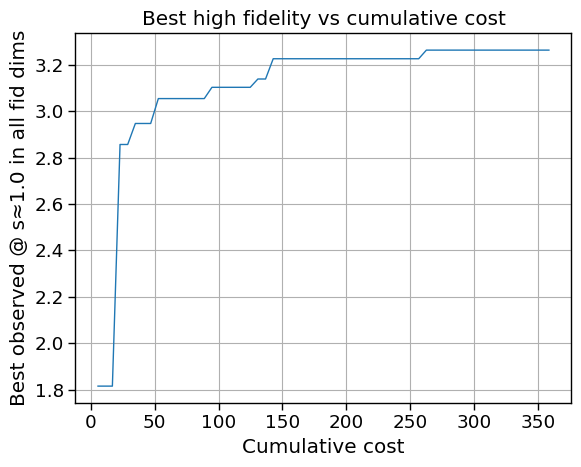

Iter 01 | s=[0.926] | y=1.570 | cost=5.926 | cum_cost=5.926 | best_hf=0.342
Iter 02 | s=[0.921] | y=1.004 | cost=5.921 | cum_cost=11.846 | best_hf=0.342
Iter 03 | s=[0.911] | y=2.471 | cost=5.911 | cum_cost=17.758 | best_hf=0.342
Iter 04 | s=[1.000] | y=1.577 | cost=6.000 | cum_cost=23.758 | best_hf=1.577
Iter 05 | s=[1.000] | y=2.660 | cost=6.000 | cum_cost=29.758 | best_hf=2.660
Iter 06 | s=[1.000] | y=3.001 | cost=6.000 | cum_cost=35.758 | best_hf=3.001
Iter 07 | s=[1.000] | y=3.076 | cost=6.000 | cum_cost=41.758 | best_hf=3.076
Iter 08 | s=[1.000] | y=2.962 | cost=6.000 | cum_cost=47.758 | best_hf=3.076
Iter 09 | s=[1.000] | y=2.768 | cost=6.000 | cum_cost=53.758 | best_hf=3.076
Iter 10 | s=[1.000] | y=2.895 | cost=6.000 | cum_cost=59.758 | best_hf=3.076
Iter 11 | s=[1.000] | y=0.002 | cost=6.000 | cum_cost=65.758 | best_hf=3.076
Iter 12 | s=[1.000] | y=0.133 | cost=6.000 | cum_cost=71.758 | best_hf=3.076
Iter 13 | s=[1.000] | y=3.263 | cost=6.000 | cum_cost=77.758 | best_hf=3.263


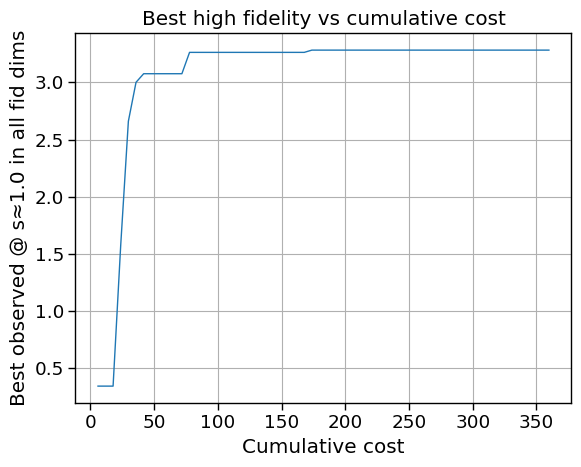

Iter 01 | s=[0.349] | y=1.552 | cost=5.349 | cum_cost=5.349 | best_hf=0.478
Iter 02 | s=[0.379] | y=0.978 | cost=5.379 | cum_cost=10.729 | best_hf=0.478
Iter 03 | s=[0.409] | y=0.524 | cost=5.409 | cum_cost=16.137 | best_hf=0.478
Iter 04 | s=[1.000] | y=1.977 | cost=6.000 | cum_cost=22.137 | best_hf=1.977
Iter 05 | s=[1.000] | y=2.061 | cost=6.000 | cum_cost=28.137 | best_hf=2.061
Iter 06 | s=[1.000] | y=1.937 | cost=6.000 | cum_cost=34.137 | best_hf=2.061
Iter 07 | s=[1.000] | y=2.357 | cost=6.000 | cum_cost=40.137 | best_hf=2.357
Iter 08 | s=[1.000] | y=2.442 | cost=6.000 | cum_cost=46.137 | best_hf=2.442
Iter 09 | s=[1.000] | y=2.881 | cost=6.000 | cum_cost=52.137 | best_hf=2.881
Iter 10 | s=[1.000] | y=2.569 | cost=6.000 | cum_cost=58.137 | best_hf=2.881
Iter 11 | s=[1.000] | y=3.083 | cost=6.000 | cum_cost=64.137 | best_hf=3.083
Iter 12 | s=[1.000] | y=3.198 | cost=6.000 | cum_cost=70.137 | best_hf=3.198
Iter 13 | s=[1.000] | y=3.171 | cost=6.000 | cum_cost=76.137 | best_hf=3.198


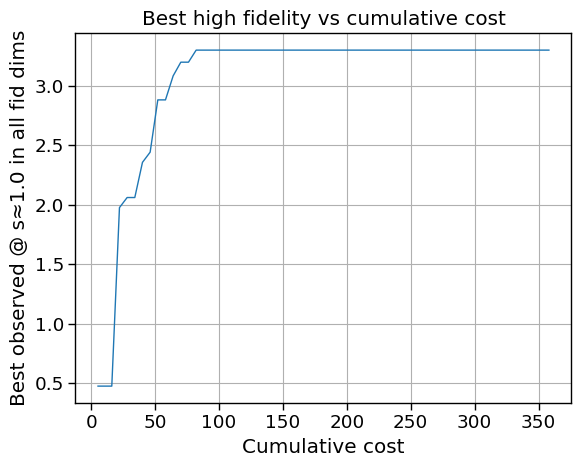

Iter 01 | s=[0.977] | y=0.731 | cost=5.977 | cum_cost=5.977 | best_hf=1.376
Iter 02 | s=[1.000] | y=1.249 | cost=6.000 | cum_cost=11.977 | best_hf=1.376
Iter 03 | s=[0.878] | y=1.639 | cost=5.878 | cum_cost=17.855 | best_hf=1.376
Iter 04 | s=[0.988] | y=1.776 | cost=5.988 | cum_cost=23.843 | best_hf=1.376
Iter 05 | s=[1.000] | y=2.054 | cost=6.000 | cum_cost=29.843 | best_hf=2.054
Iter 06 | s=[1.000] | y=1.781 | cost=6.000 | cum_cost=35.843 | best_hf=2.054
Iter 07 | s=[1.000] | y=2.357 | cost=6.000 | cum_cost=41.843 | best_hf=2.357
Iter 08 | s=[1.000] | y=2.210 | cost=6.000 | cum_cost=47.843 | best_hf=2.357
Iter 09 | s=[1.000] | y=2.323 | cost=6.000 | cum_cost=53.843 | best_hf=2.357
Iter 10 | s=[1.000] | y=2.201 | cost=6.000 | cum_cost=59.843 | best_hf=2.357
Iter 11 | s=[1.000] | y=2.785 | cost=6.000 | cum_cost=65.843 | best_hf=2.785
Iter 12 | s=[1.000] | y=2.869 | cost=6.000 | cum_cost=71.843 | best_hf=2.869
Iter 13 | s=[1.000] | y=2.895 | cost=6.000 | cum_cost=77.843 | best_hf=2.895


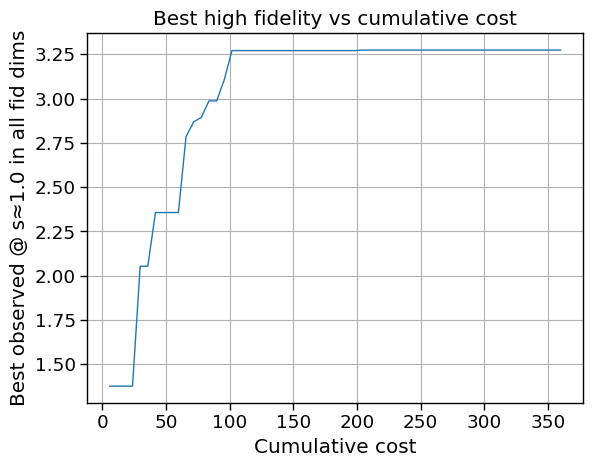

Iter 01 | s=[0.159] | y=1.766 | cost=5.159 | cum_cost=5.159 | best_hf=0.266
Iter 02 | s=[0.379] | y=1.263 | cost=5.379 | cum_cost=10.538 | best_hf=0.266
Iter 03 | s=[0.359] | y=1.899 | cost=5.359 | cum_cost=15.898 | best_hf=0.266
Iter 04 | s=[0.510] | y=1.138 | cost=5.510 | cum_cost=21.408 | best_hf=0.266
Iter 05 | s=[0.467] | y=2.179 | cost=5.467 | cum_cost=26.875 | best_hf=0.266
Iter 06 | s=[0.571] | y=2.704 | cost=5.571 | cum_cost=32.446 | best_hf=0.266
Iter 07 | s=[1.000] | y=0.120 | cost=6.000 | cum_cost=38.446 | best_hf=0.266
Iter 08 | s=[0.787] | y=2.993 | cost=5.787 | cum_cost=44.233 | best_hf=0.266
Iter 09 | s=[0.917] | y=2.721 | cost=5.917 | cum_cost=50.150 | best_hf=0.266
Iter 10 | s=[0.912] | y=2.832 | cost=5.912 | cum_cost=56.062 | best_hf=0.266
Iter 11 | s=[0.871] | y=3.148 | cost=5.871 | cum_cost=61.933 | best_hf=0.266
Iter 12 | s=[0.927] | y=3.181 | cost=5.927 | cum_cost=67.859 | best_hf=0.266
Iter 13 | s=[1.000] | y=3.292 | cost=6.000 | cum_cost=73.859 | best_hf=3.292


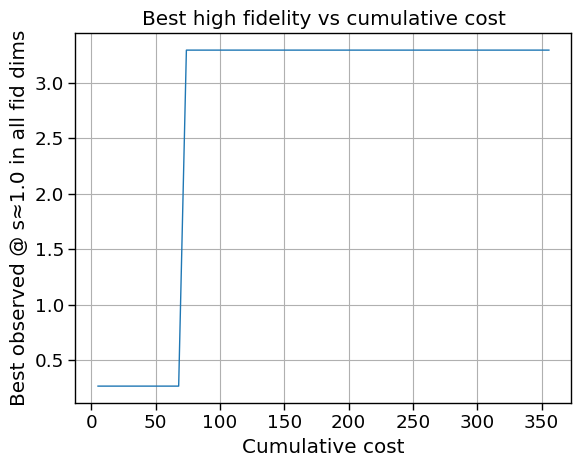

Iter 01 | s=[1.000] | y=1.271 | cost=6.000 | cum_cost=6.000 | best_hf=1.271
Iter 02 | s=[1.000] | y=1.742 | cost=6.000 | cum_cost=12.000 | best_hf=1.742
Iter 03 | s=[1.000] | y=2.347 | cost=6.000 | cum_cost=18.000 | best_hf=2.347
Iter 04 | s=[1.000] | y=1.269 | cost=6.000 | cum_cost=24.000 | best_hf=2.347
Iter 05 | s=[1.000] | y=2.703 | cost=6.000 | cum_cost=30.000 | best_hf=2.703
Iter 06 | s=[1.000] | y=2.831 | cost=6.000 | cum_cost=36.000 | best_hf=2.831
Iter 07 | s=[1.000] | y=0.126 | cost=6.000 | cum_cost=42.000 | best_hf=2.831
Iter 08 | s=[1.000] | y=3.050 | cost=6.000 | cum_cost=48.000 | best_hf=3.050
Iter 09 | s=[1.000] | y=2.836 | cost=6.000 | cum_cost=54.000 | best_hf=3.050
Iter 10 | s=[1.000] | y=2.873 | cost=6.000 | cum_cost=60.000 | best_hf=3.050
Iter 11 | s=[1.000] | y=3.101 | cost=6.000 | cum_cost=66.000 | best_hf=3.101
Iter 12 | s=[1.000] | y=3.139 | cost=6.000 | cum_cost=72.000 | best_hf=3.139
Iter 13 | s=[1.000] | y=3.269 | cost=6.000 | cum_cost=78.000 | best_hf=3.269


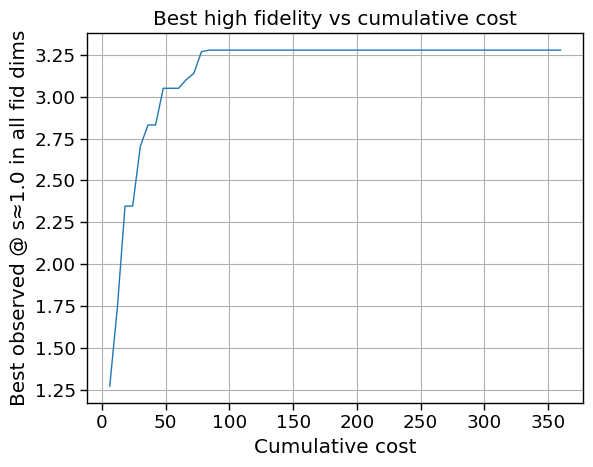

Saved aggregate stats → mf_kg_cont_runs_hartmann_32.csv


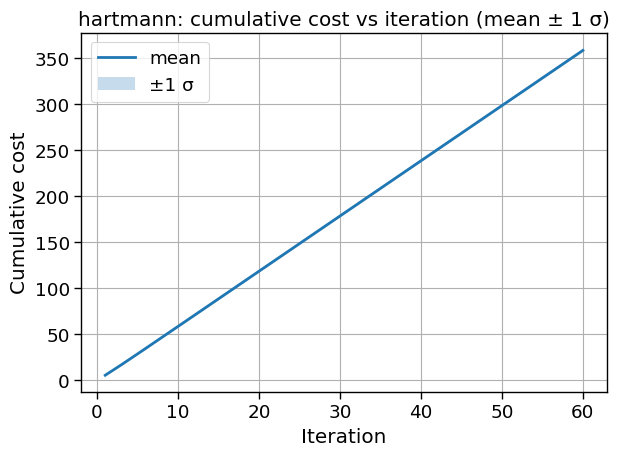

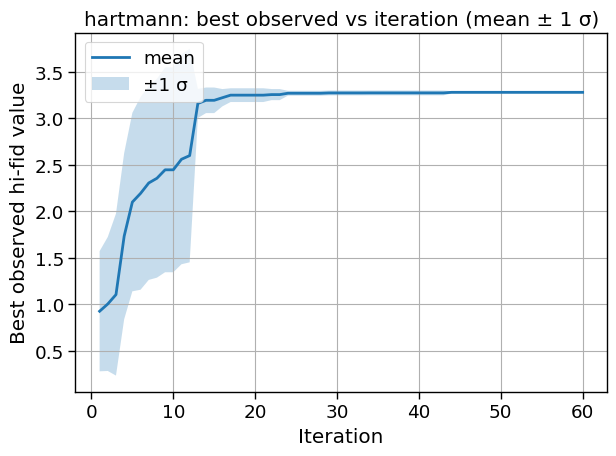

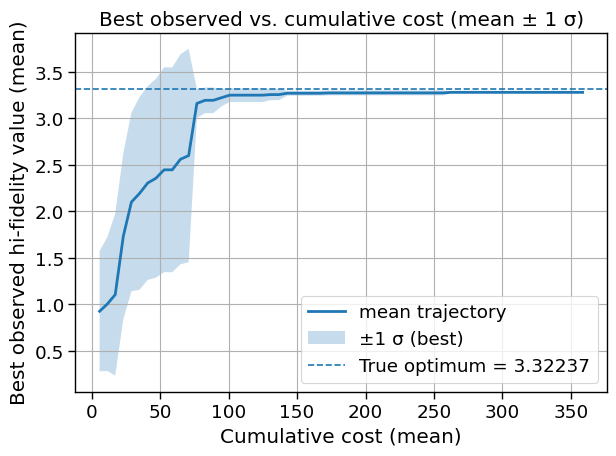


=== Running branin (iters=50) ===
Iter 01 | s=[1.000] | y=-2.783 | cost=6.000 | cum_cost=6.000 | best_hf=-1.860
Iter 02 | s=[1.000] | y=-13.145 | cost=6.000 | cum_cost=12.000 | best_hf=-1.860
Iter 03 | s=[1.000] | y=-0.567 | cost=6.000 | cum_cost=18.000 | best_hf=-0.567
Iter 04 | s=[1.000] | y=-2.241 | cost=6.000 | cum_cost=24.000 | best_hf=-0.567
Iter 05 | s=[0.980] | y=-8.074 | cost=5.980 | cum_cost=29.980 | best_hf=-0.567
Iter 06 | s=[0.196] | y=-28.981 | cost=5.196 | cum_cost=35.176 | best_hf=-0.567
Iter 07 | s=[0.984] | y=-2.680 | cost=5.984 | cum_cost=41.160 | best_hf=-0.567
Iter 08 | s=[0.993] | y=-2.940 | cost=5.993 | cum_cost=47.153 | best_hf=-0.567
Iter 09 | s=[0.928] | y=-7.802 | cost=5.928 | cum_cost=53.081 | best_hf=-0.567
Iter 10 | s=[0.981] | y=-0.460 | cost=5.981 | cum_cost=59.062 | best_hf=-0.567
Iter 11 | s=[1.000] | y=-18.169 | cost=6.000 | cum_cost=65.062 | best_hf=-0.567
Iter 12 | s=[0.971] | y=-3.698 | cost=5.971 | cum_cost=71.034 | best_hf=-0.567
Iter 13 | s=[0.

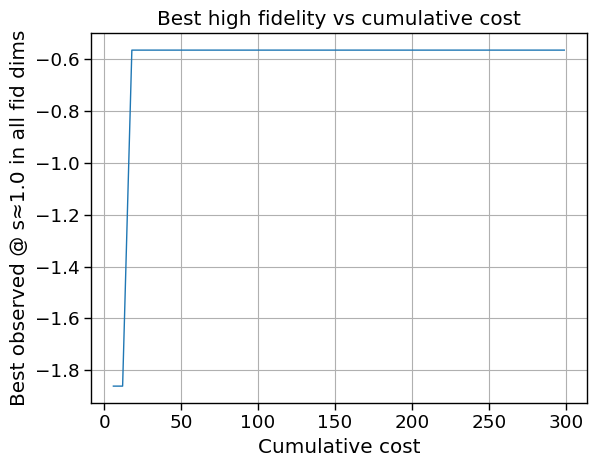

Iter 01 | s=[1.000] | y=-1.061 | cost=6.000 | cum_cost=6.000 | best_hf=-1.061
Iter 02 | s=[1.000] | y=-10.995 | cost=6.000 | cum_cost=12.000 | best_hf=-1.061
Iter 03 | s=[1.000] | y=-3.980 | cost=6.000 | cum_cost=18.000 | best_hf=-1.061
Iter 04 | s=[1.000] | y=-6.793 | cost=6.000 | cum_cost=24.000 | best_hf=-1.061
Iter 05 | s=[1.000] | y=-2.939 | cost=6.000 | cum_cost=30.000 | best_hf=-1.061
Iter 06 | s=[1.000] | y=-1.016 | cost=6.000 | cum_cost=36.000 | best_hf=-1.016
Iter 07 | s=[1.000] | y=-17.027 | cost=6.000 | cum_cost=42.000 | best_hf=-1.016
Iter 08 | s=[1.000] | y=-3.606 | cost=6.000 | cum_cost=48.000 | best_hf=-1.016
Iter 09 | s=[0.943] | y=-3.169 | cost=5.943 | cum_cost=53.943 | best_hf=-1.016
Iter 10 | s=[0.994] | y=-0.647 | cost=5.994 | cum_cost=59.937 | best_hf=-0.647
Iter 11 | s=[1.000] | y=-5.519 | cost=6.000 | cum_cost=65.937 | best_hf=-0.647
Iter 12 | s=[1.000] | y=-4.037 | cost=6.000 | cum_cost=71.937 | best_hf=-0.647
Iter 13 | s=[1.000] | y=-11.902 | cost=6.000 | cum_

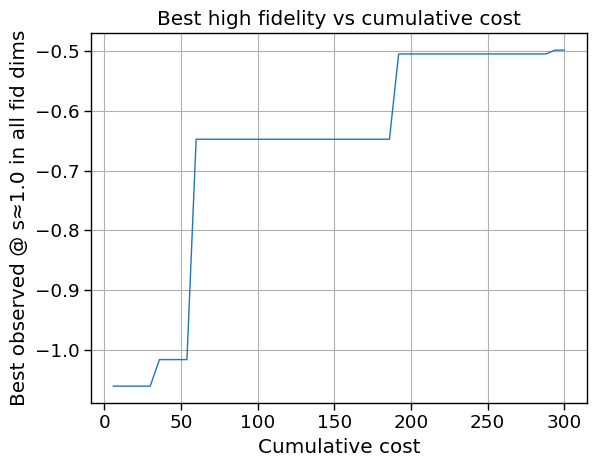

Iter 01 | s=[1.000] | y=-6.563 | cost=6.000 | cum_cost=6.000 | best_hf=-4.416
Iter 02 | s=[1.000] | y=-5.365 | cost=6.000 | cum_cost=12.000 | best_hf=-4.416
Iter 03 | s=[1.000] | y=-9.033 | cost=6.000 | cum_cost=18.000 | best_hf=-4.416
Iter 04 | s=[1.000] | y=-3.065 | cost=6.000 | cum_cost=24.000 | best_hf=-3.065
Iter 05 | s=[0.966] | y=-3.425 | cost=5.966 | cum_cost=29.966 | best_hf=-3.065
Iter 06 | s=[1.000] | y=-3.033 | cost=6.000 | cum_cost=35.966 | best_hf=-3.033
Iter 07 | s=[1.000] | y=-0.646 | cost=6.000 | cum_cost=41.966 | best_hf=-0.646
Iter 08 | s=[1.000] | y=-18.889 | cost=6.000 | cum_cost=47.966 | best_hf=-0.646
Iter 09 | s=[1.000] | y=-2.537 | cost=6.000 | cum_cost=53.966 | best_hf=-0.646
Iter 10 | s=[1.000] | y=-0.475 | cost=6.000 | cum_cost=59.966 | best_hf=-0.475
Iter 11 | s=[1.000] | y=-7.452 | cost=6.000 | cum_cost=65.966 | best_hf=-0.475
Iter 12 | s=[1.000] | y=-11.696 | cost=6.000 | cum_cost=71.966 | best_hf=-0.475
Iter 13 | s=[1.000] | y=-143.067 | cost=6.000 | cum

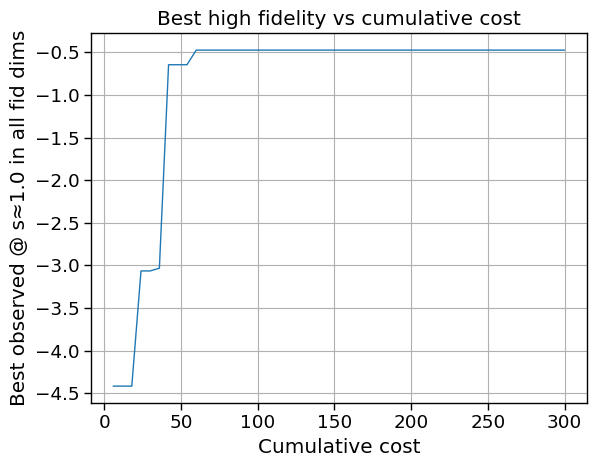

Iter 01 | s=[1.000] | y=-10.885 | cost=6.000 | cum_cost=6.000 | best_hf=-10.885
Iter 02 | s=[0.963] | y=-15.692 | cost=5.963 | cum_cost=11.963 | best_hf=-10.885
Iter 03 | s=[0.961] | y=-10.358 | cost=5.961 | cum_cost=17.923 | best_hf=-10.885
Iter 04 | s=[1.000] | y=-25.995 | cost=6.000 | cum_cost=23.923 | best_hf=-10.885
Iter 05 | s=[0.972] | y=-2.458 | cost=5.972 | cum_cost=29.895 | best_hf=-10.885
Iter 06 | s=[1.000] | y=-2.617 | cost=6.000 | cum_cost=35.895 | best_hf=-2.617
Iter 07 | s=[0.948] | y=-8.031 | cost=5.948 | cum_cost=41.844 | best_hf=-2.617
Iter 08 | s=[0.957] | y=-5.433 | cost=5.957 | cum_cost=47.800 | best_hf=-2.617
Iter 09 | s=[0.982] | y=-2.995 | cost=5.982 | cum_cost=53.782 | best_hf=-2.617
Iter 10 | s=[0.966] | y=-5.541 | cost=5.966 | cum_cost=59.748 | best_hf=-2.617
Iter 11 | s=[0.992] | y=-1.154 | cost=5.992 | cum_cost=65.740 | best_hf=-1.154
Iter 12 | s=[0.975] | y=-8.584 | cost=5.975 | cum_cost=71.715 | best_hf=-1.154
Iter 13 | s=[1.000] | y=-3.289 | cost=6.000 

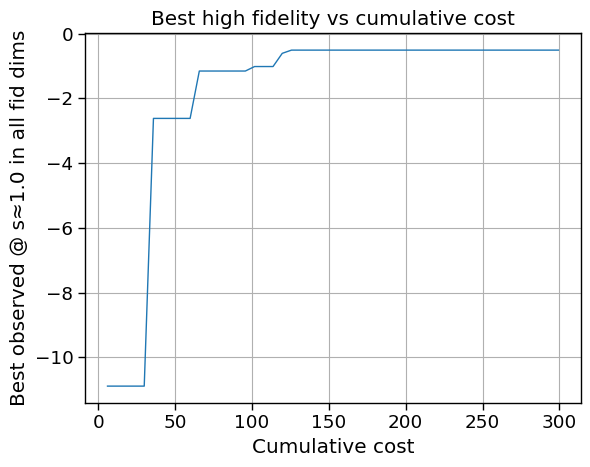

Iter 01 | s=[0.965] | y=-18.377 | cost=5.965 | cum_cost=5.965 | best_hf=-21.199
Iter 02 | s=[1.000] | y=-17.879 | cost=6.000 | cum_cost=11.965 | best_hf=-17.879
Iter 03 | s=[1.000] | y=-20.869 | cost=6.000 | cum_cost=17.965 | best_hf=-17.879
Iter 04 | s=[1.000] | y=-12.324 | cost=6.000 | cum_cost=23.965 | best_hf=-12.324
Iter 05 | s=[0.990] | y=-20.728 | cost=5.990 | cum_cost=29.955 | best_hf=-12.324
Iter 06 | s=[1.000] | y=-2.100 | cost=6.000 | cum_cost=35.955 | best_hf=-2.100
Iter 07 | s=[1.000] | y=-1.807 | cost=6.000 | cum_cost=41.955 | best_hf=-1.807
Iter 08 | s=[0.990] | y=-0.778 | cost=5.990 | cum_cost=47.945 | best_hf=-0.778
Iter 09 | s=[1.000] | y=-3.541 | cost=6.000 | cum_cost=53.945 | best_hf=-0.778
Iter 10 | s=[1.000] | y=-15.610 | cost=6.000 | cum_cost=59.945 | best_hf=-0.778
Iter 11 | s=[1.000] | y=-7.131 | cost=6.000 | cum_cost=65.945 | best_hf=-0.778
Iter 12 | s=[1.000] | y=-8.887 | cost=6.000 | cum_cost=71.945 | best_hf=-0.778
Iter 13 | s=[1.000] | y=-4.796 | cost=6.00

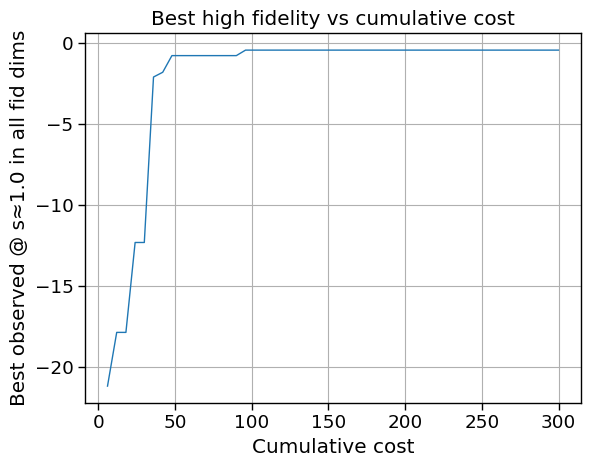

Iter 01 | s=[1.000] | y=-0.664 | cost=6.000 | cum_cost=6.000 | best_hf=-0.545
Iter 02 | s=[1.000] | y=-0.920 | cost=6.000 | cum_cost=12.000 | best_hf=-0.545
Iter 03 | s=[1.000] | y=-6.489 | cost=6.000 | cum_cost=18.000 | best_hf=-0.545
Iter 04 | s=[1.000] | y=-5.853 | cost=6.000 | cum_cost=24.000 | best_hf=-0.545
Iter 05 | s=[0.960] | y=-6.064 | cost=5.960 | cum_cost=29.960 | best_hf=-0.545
Iter 06 | s=[1.000] | y=-9.768 | cost=6.000 | cum_cost=35.960 | best_hf=-0.545
Iter 07 | s=[0.963] | y=-1.559 | cost=5.963 | cum_cost=41.922 | best_hf=-0.545
Iter 08 | s=[0.937] | y=-5.516 | cost=5.937 | cum_cost=47.859 | best_hf=-0.545
Iter 09 | s=[0.992] | y=-6.616 | cost=5.992 | cum_cost=53.851 | best_hf=-0.545
Iter 10 | s=[1.000] | y=-9.653 | cost=6.000 | cum_cost=59.851 | best_hf=-0.545
Iter 11 | s=[1.000] | y=-7.330 | cost=6.000 | cum_cost=65.851 | best_hf=-0.545
Iter 12 | s=[0.924] | y=-3.072 | cost=5.924 | cum_cost=71.776 | best_hf=-0.545
Iter 13 | s=[1.000] | y=-10.598 | cost=6.000 | cum_co

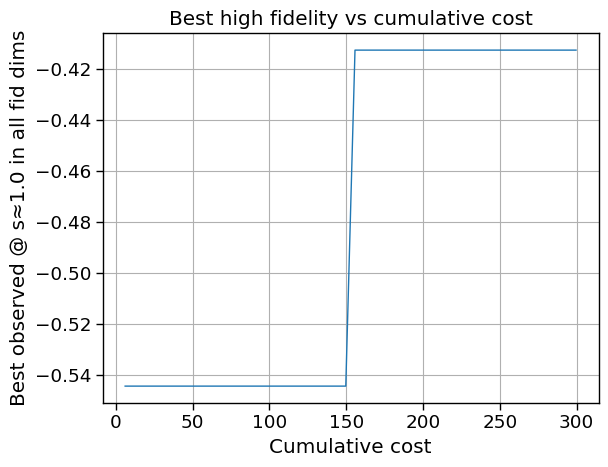

Saved aggregate stats → mf_kg_cont_runs_branin_32.csv


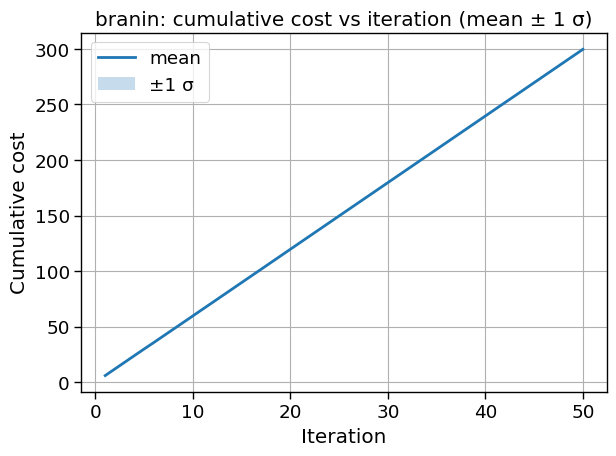

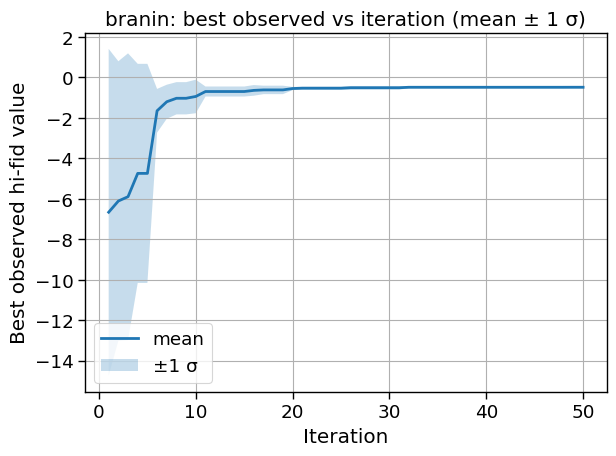

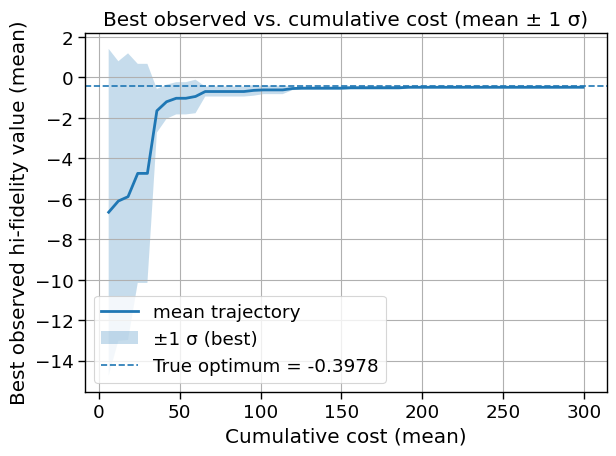


=== Running bukin (iters=50) ===
Iter 01 | s=[1.000] | y=-43.089 | cost=6.000 | cum_cost=6.000 | best_hf=-40.905
Iter 02 | s=[1.000] | y=-39.298 | cost=6.000 | cum_cost=12.000 | best_hf=-39.298
Iter 03 | s=[1.000] | y=-59.721 | cost=6.000 | cum_cost=18.000 | best_hf=-39.298
Iter 04 | s=[1.000] | y=-32.126 | cost=6.000 | cum_cost=24.000 | best_hf=-32.126
Iter 05 | s=[1.000] | y=-52.725 | cost=6.000 | cum_cost=30.000 | best_hf=-32.126
Iter 06 | s=[1.000] | y=-180.009 | cost=6.000 | cum_cost=36.000 | best_hf=-32.126
Iter 07 | s=[1.000] | y=-51.531 | cost=6.000 | cum_cost=42.000 | best_hf=-32.126
Iter 08 | s=[1.000] | y=-41.887 | cost=6.000 | cum_cost=48.000 | best_hf=-32.126
Iter 09 | s=[1.000] | y=-35.987 | cost=6.000 | cum_cost=54.000 | best_hf=-32.126
Iter 10 | s=[1.000] | y=-24.784 | cost=6.000 | cum_cost=60.000 | best_hf=-24.784
Iter 11 | s=[1.000] | y=-40.111 | cost=6.000 | cum_cost=66.000 | best_hf=-24.784
Iter 12 | s=[1.000] | y=-42.078 | cost=6.000 | cum_cost=72.000 | best_hf=-2

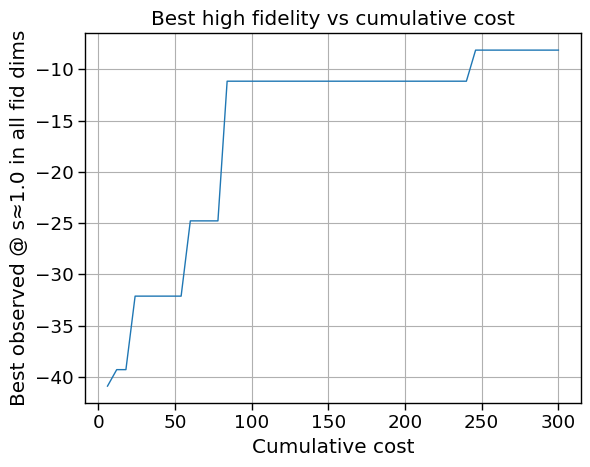

Iter 01 | s=[0.889] | y=-49.064 | cost=5.889 | cum_cost=5.889 | best_hf=-45.793
Iter 02 | s=[0.812] | y=-18.572 | cost=5.812 | cum_cost=11.701 | best_hf=-45.793
Iter 03 | s=[1.000] | y=-28.315 | cost=6.000 | cum_cost=17.701 | best_hf=-28.315
Iter 04 | s=[1.000] | y=-22.574 | cost=6.000 | cum_cost=23.701 | best_hf=-22.574
Iter 05 | s=[1.000] | y=-47.015 | cost=6.000 | cum_cost=29.701 | best_hf=-22.574
Iter 06 | s=[1.000] | y=-55.217 | cost=6.000 | cum_cost=35.701 | best_hf=-22.574
Iter 07 | s=[1.000] | y=-37.939 | cost=6.000 | cum_cost=41.701 | best_hf=-22.574
Iter 08 | s=[1.000] | y=-41.327 | cost=6.000 | cum_cost=47.701 | best_hf=-22.574
Iter 09 | s=[1.000] | y=-31.603 | cost=6.000 | cum_cost=53.701 | best_hf=-22.574
Iter 10 | s=[1.000] | y=-37.167 | cost=6.000 | cum_cost=59.701 | best_hf=-22.574
Iter 11 | s=[1.000] | y=-187.360 | cost=6.000 | cum_cost=65.701 | best_hf=-22.574
Iter 12 | s=[1.000] | y=-194.955 | cost=6.000 | cum_cost=71.701 | best_hf=-22.574
Iter 13 | s=[1.000] | y=-13

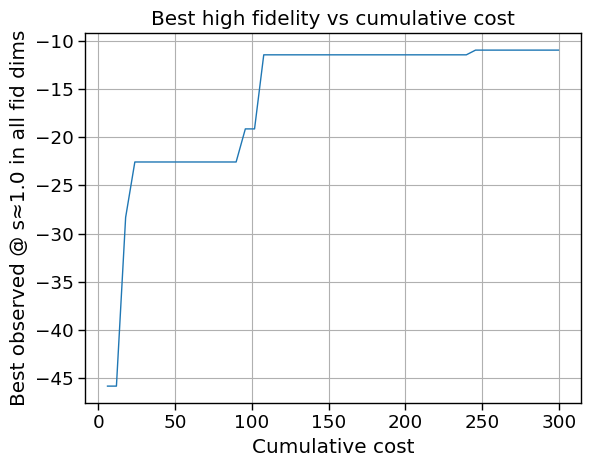

Iter 01 | s=[1.000] | y=-51.670 | cost=6.000 | cum_cost=6.000 | best_hf=-23.313
Iter 02 | s=[1.000] | y=-24.340 | cost=6.000 | cum_cost=12.000 | best_hf=-23.313
Iter 03 | s=[1.000] | y=-46.207 | cost=6.000 | cum_cost=18.000 | best_hf=-23.313
Iter 04 | s=[1.000] | y=-229.163 | cost=6.000 | cum_cost=24.000 | best_hf=-23.313
Iter 05 | s=[1.000] | y=-180.320 | cost=6.000 | cum_cost=30.000 | best_hf=-23.313
Iter 06 | s=[1.000] | y=-165.776 | cost=6.000 | cum_cost=36.000 | best_hf=-23.313
Iter 07 | s=[1.000] | y=-42.340 | cost=6.000 | cum_cost=42.000 | best_hf=-23.313
Iter 08 | s=[1.000] | y=-49.272 | cost=6.000 | cum_cost=48.000 | best_hf=-23.313
Iter 09 | s=[1.000] | y=-52.747 | cost=6.000 | cum_cost=54.000 | best_hf=-23.313
Iter 10 | s=[1.000] | y=-32.871 | cost=6.000 | cum_cost=60.000 | best_hf=-23.313
Iter 11 | s=[1.000] | y=-229.179 | cost=6.000 | cum_cost=66.000 | best_hf=-23.313
Iter 12 | s=[1.000] | y=-197.318 | cost=6.000 | cum_cost=72.000 | best_hf=-23.313
Iter 13 | s=[1.000] | y=

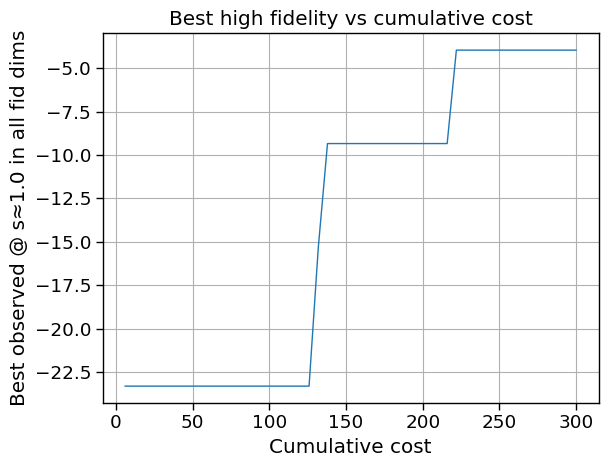

Iter 01 | s=[1.000] | y=-191.194 | cost=6.000 | cum_cost=6.000 | best_hf=-51.495
Iter 02 | s=[1.000] | y=-20.822 | cost=6.000 | cum_cost=12.000 | best_hf=-20.822
Iter 03 | s=[1.000] | y=-207.813 | cost=6.000 | cum_cost=18.000 | best_hf=-20.822
Iter 04 | s=[1.000] | y=-24.853 | cost=6.000 | cum_cost=24.000 | best_hf=-20.822
Iter 05 | s=[1.000] | y=-53.205 | cost=6.000 | cum_cost=30.000 | best_hf=-20.822
Iter 06 | s=[1.000] | y=-49.749 | cost=6.000 | cum_cost=36.000 | best_hf=-20.822
Iter 07 | s=[1.000] | y=-11.793 | cost=6.000 | cum_cost=42.000 | best_hf=-11.793
Iter 08 | s=[1.000] | y=-53.624 | cost=6.000 | cum_cost=48.000 | best_hf=-11.793
Iter 09 | s=[1.000] | y=-131.168 | cost=6.000 | cum_cost=54.000 | best_hf=-11.793
Iter 10 | s=[1.000] | y=-39.476 | cost=6.000 | cum_cost=60.000 | best_hf=-11.793
Iter 11 | s=[1.000] | y=-127.411 | cost=6.000 | cum_cost=66.000 | best_hf=-11.793
Iter 12 | s=[1.000] | y=-203.311 | cost=6.000 | cum_cost=72.000 | best_hf=-11.793
Iter 13 | s=[1.000] | y=

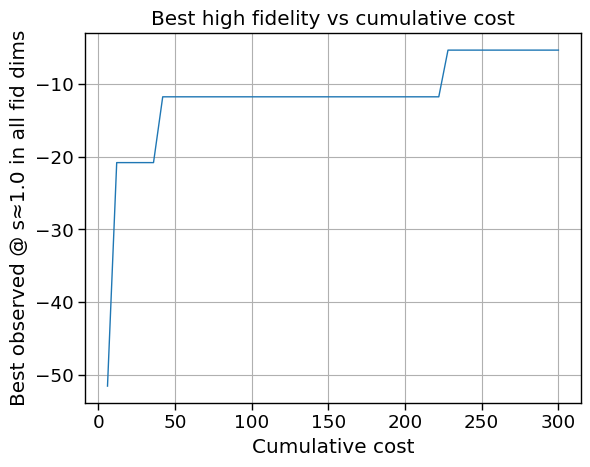

Iter 01 | s=[0.843] | y=-29.940 | cost=5.843 | cum_cost=5.843 | best_hf=-84.364
Iter 02 | s=[1.000] | y=-44.579 | cost=6.000 | cum_cost=11.843 | best_hf=-44.579
Iter 03 | s=[1.000] | y=-33.456 | cost=6.000 | cum_cost=17.843 | best_hf=-33.456
Iter 04 | s=[0.887] | y=-45.387 | cost=5.887 | cum_cost=23.730 | best_hf=-33.456
Iter 05 | s=[1.000] | y=-101.582 | cost=6.000 | cum_cost=29.730 | best_hf=-33.456
Iter 06 | s=[1.000] | y=-22.266 | cost=6.000 | cum_cost=35.730 | best_hf=-22.266
Iter 07 | s=[1.000] | y=-229.014 | cost=6.000 | cum_cost=41.730 | best_hf=-22.266
Iter 08 | s=[1.000] | y=-136.876 | cost=6.000 | cum_cost=47.730 | best_hf=-22.266
Iter 09 | s=[1.000] | y=-41.903 | cost=6.000 | cum_cost=53.730 | best_hf=-22.266
Iter 10 | s=[1.000] | y=-57.219 | cost=6.000 | cum_cost=59.730 | best_hf=-22.266
Iter 11 | s=[1.000] | y=-3.711 | cost=6.000 | cum_cost=65.730 | best_hf=-3.711
Iter 12 | s=[1.000] | y=-52.553 | cost=6.000 | cum_cost=71.730 | best_hf=-3.711
Iter 13 | s=[1.000] | y=-51.4

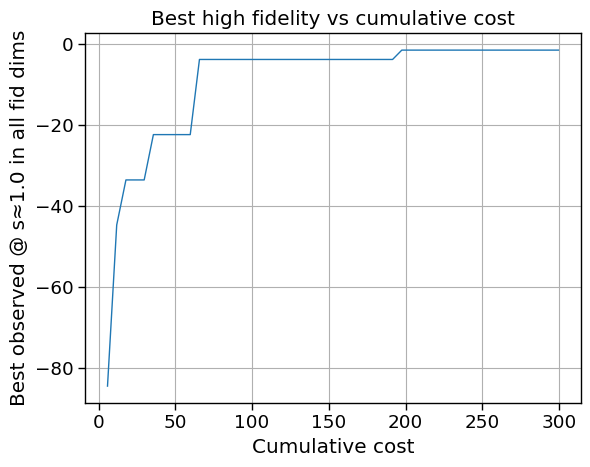

Iter 01 | s=[1.000] | y=-27.735 | cost=6.000 | cum_cost=6.000 | best_hf=-27.735
Iter 02 | s=[0.968] | y=-47.364 | cost=5.968 | cum_cost=11.968 | best_hf=-27.735
Iter 03 | s=[1.000] | y=-194.841 | cost=6.000 | cum_cost=17.968 | best_hf=-27.735
Iter 04 | s=[0.997] | y=-48.216 | cost=5.997 | cum_cost=23.964 | best_hf=-27.735
Iter 05 | s=[1.000] | y=-63.787 | cost=6.000 | cum_cost=29.964 | best_hf=-27.735
Iter 06 | s=[1.000] | y=-39.873 | cost=6.000 | cum_cost=35.964 | best_hf=-27.735
Iter 07 | s=[1.000] | y=-34.405 | cost=6.000 | cum_cost=41.964 | best_hf=-27.735
Iter 08 | s=[1.000] | y=-35.844 | cost=6.000 | cum_cost=47.964 | best_hf=-27.735
Iter 09 | s=[1.000] | y=-39.760 | cost=6.000 | cum_cost=53.964 | best_hf=-27.735
Iter 10 | s=[1.000] | y=-68.190 | cost=6.000 | cum_cost=59.964 | best_hf=-27.735
Iter 11 | s=[0.992] | y=-26.549 | cost=5.992 | cum_cost=65.957 | best_hf=-26.549
Iter 12 | s=[1.000] | y=-51.080 | cost=6.000 | cum_cost=71.957 | best_hf=-26.549
Iter 13 | s=[1.000] | y=-24.

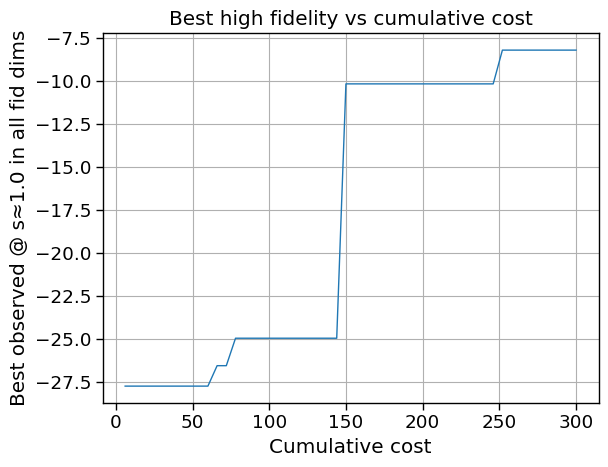

Saved aggregate stats → mf_kg_cont_runs_bukin_32.csv


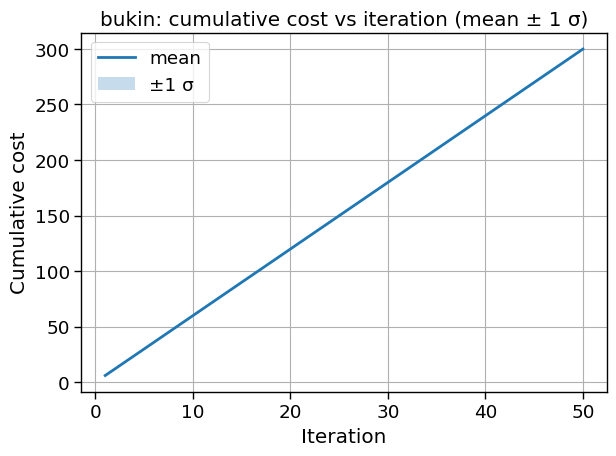

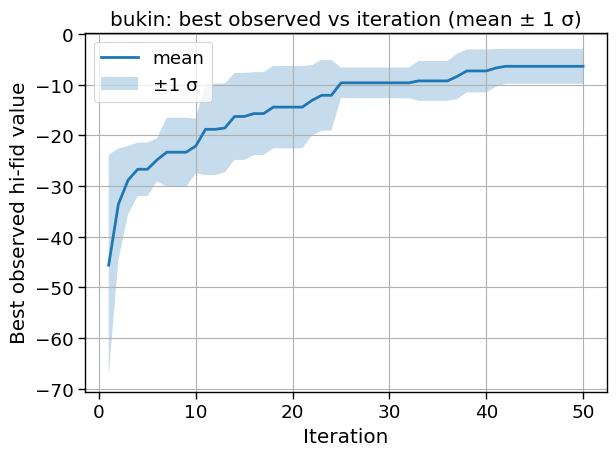

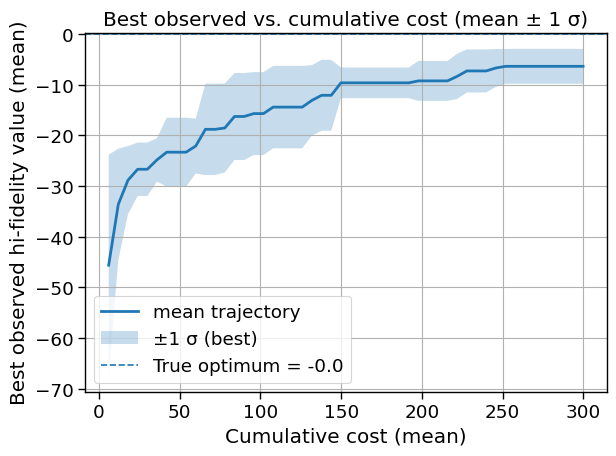


=== Running ackley (iters=57) ===
Iter 01 | s=[0.000] | y=-19.542 | cost=5.000 | cum_cost=5.000 | best_hf=-20.154
Iter 02 | s=[1.000] | y=-20.839 | cost=6.000 | cum_cost=11.000 | best_hf=-20.154
Iter 03 | s=[1.000] | y=-20.337 | cost=6.000 | cum_cost=17.000 | best_hf=-20.154
Iter 04 | s=[0.000] | y=-20.501 | cost=5.000 | cum_cost=22.000 | best_hf=-20.154
Iter 05 | s=[1.000] | y=-18.718 | cost=6.000 | cum_cost=28.000 | best_hf=-18.718
Iter 06 | s=[0.000] | y=-18.137 | cost=5.000 | cum_cost=33.000 | best_hf=-18.718
Iter 07 | s=[0.000] | y=-19.299 | cost=5.000 | cum_cost=38.000 | best_hf=-18.718
Iter 08 | s=[1.000] | y=-20.863 | cost=6.000 | cum_cost=44.000 | best_hf=-18.718
Iter 09 | s=[1.000] | y=-21.208 | cost=6.000 | cum_cost=50.000 | best_hf=-18.718
Iter 10 | s=[1.000] | y=-21.222 | cost=6.000 | cum_cost=56.000 | best_hf=-18.718
Iter 11 | s=[0.000] | y=-9.913 | cost=5.000 | cum_cost=61.000 | best_hf=-18.718
Iter 12 | s=[1.000] | y=-19.748 | cost=6.000 | cum_cost=67.000 | best_hf=-18

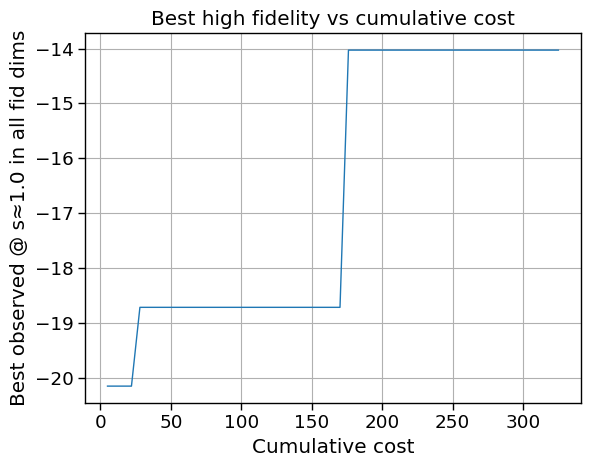

Iter 01 | s=[1.000] | y=-21.189 | cost=6.000 | cum_cost=6.000 | best_hf=-19.883
Iter 02 | s=[0.000] | y=-19.495 | cost=5.000 | cum_cost=11.000 | best_hf=-19.883
Iter 03 | s=[1.000] | y=-21.479 | cost=6.000 | cum_cost=17.000 | best_hf=-19.883
Iter 04 | s=[0.000] | y=-19.373 | cost=5.000 | cum_cost=22.000 | best_hf=-19.883
Iter 05 | s=[1.000] | y=-14.601 | cost=6.000 | cum_cost=28.000 | best_hf=-14.601
Iter 06 | s=[1.000] | y=-21.487 | cost=6.000 | cum_cost=34.000 | best_hf=-14.601
Iter 07 | s=[0.000] | y=-19.057 | cost=5.000 | cum_cost=39.000 | best_hf=-14.601
Iter 08 | s=[1.000] | y=-21.197 | cost=6.000 | cum_cost=45.000 | best_hf=-14.601
Iter 09 | s=[1.000] | y=-21.402 | cost=6.000 | cum_cost=51.000 | best_hf=-14.601
Iter 10 | s=[0.000] | y=-18.730 | cost=5.000 | cum_cost=56.000 | best_hf=-14.601
Iter 11 | s=[1.000] | y=-20.825 | cost=6.000 | cum_cost=62.000 | best_hf=-14.601
Iter 12 | s=[1.000] | y=-21.719 | cost=6.000 | cum_cost=68.000 | best_hf=-14.601
Iter 13 | s=[0.000] | y=-17.2

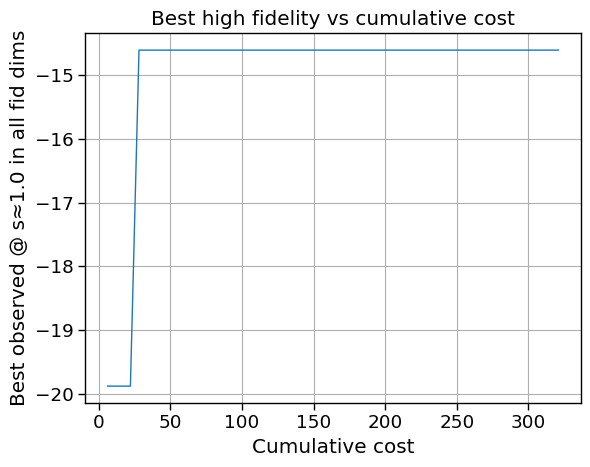

Iter 01 | s=[1.000] | y=-21.727 | cost=6.000 | cum_cost=6.000 | best_hf=-19.248
Iter 02 | s=[1.000] | y=-16.350 | cost=6.000 | cum_cost=12.000 | best_hf=-16.350
Iter 03 | s=[1.000] | y=-20.972 | cost=6.000 | cum_cost=18.000 | best_hf=-16.350
Iter 04 | s=[1.000] | y=-21.166 | cost=6.000 | cum_cost=24.000 | best_hf=-16.350
Iter 05 | s=[1.000] | y=-20.467 | cost=6.000 | cum_cost=30.000 | best_hf=-16.350
Iter 06 | s=[0.000] | y=-20.503 | cost=5.000 | cum_cost=35.000 | best_hf=-16.350
Iter 07 | s=[1.000] | y=-21.903 | cost=6.000 | cum_cost=41.000 | best_hf=-16.350
Iter 08 | s=[0.000] | y=-18.691 | cost=5.000 | cum_cost=46.000 | best_hf=-16.350
Iter 09 | s=[1.000] | y=-20.501 | cost=6.000 | cum_cost=52.000 | best_hf=-16.350
Iter 10 | s=[1.000] | y=-18.493 | cost=6.000 | cum_cost=58.000 | best_hf=-16.350
Iter 11 | s=[0.000] | y=-18.742 | cost=5.000 | cum_cost=63.000 | best_hf=-16.350
Iter 12 | s=[0.000] | y=-19.130 | cost=5.000 | cum_cost=68.000 | best_hf=-16.350
Iter 13 | s=[1.000] | y=-20.8

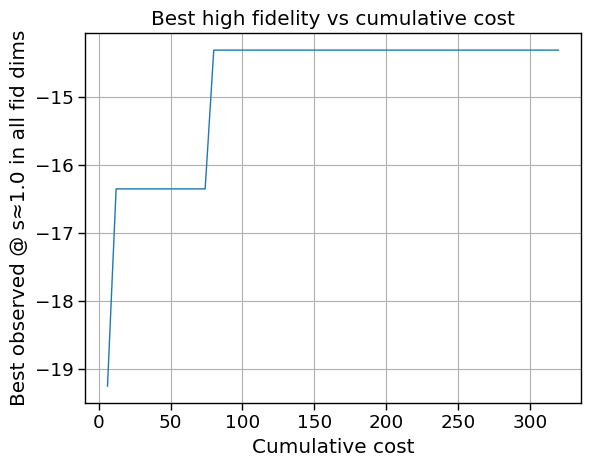

Iter 01 | s=[1.000] | y=-21.892 | cost=6.000 | cum_cost=6.000 | best_hf=-20.017
Iter 02 | s=[0.000] | y=-19.167 | cost=5.000 | cum_cost=11.000 | best_hf=-20.017
Iter 03 | s=[0.000] | y=-17.189 | cost=5.000 | cum_cost=16.000 | best_hf=-20.017
Iter 04 | s=[0.000] | y=-19.507 | cost=5.000 | cum_cost=21.000 | best_hf=-20.017
Iter 05 | s=[1.000] | y=-21.247 | cost=6.000 | cum_cost=27.000 | best_hf=-20.017
Iter 06 | s=[0.000] | y=-17.534 | cost=5.000 | cum_cost=32.000 | best_hf=-20.017
Iter 07 | s=[1.000] | y=-20.980 | cost=6.000 | cum_cost=38.000 | best_hf=-20.017
Iter 08 | s=[1.000] | y=-21.544 | cost=6.000 | cum_cost=44.000 | best_hf=-20.017
Iter 09 | s=[0.000] | y=-19.764 | cost=5.000 | cum_cost=49.000 | best_hf=-20.017
Iter 10 | s=[1.000] | y=-21.310 | cost=6.000 | cum_cost=55.000 | best_hf=-20.017
Iter 11 | s=[1.000] | y=-18.494 | cost=6.000 | cum_cost=61.000 | best_hf=-18.494
Iter 12 | s=[0.000] | y=-19.099 | cost=5.000 | cum_cost=66.000 | best_hf=-18.494
Iter 13 | s=[1.000] | y=-19.7

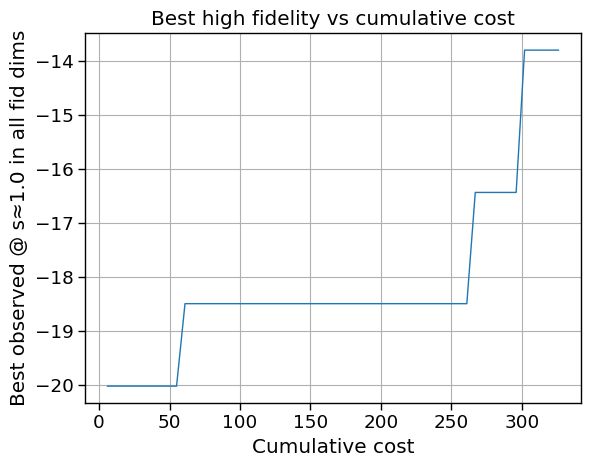

Iter 01 | s=[1.000] | y=-21.297 | cost=6.000 | cum_cost=6.000 | best_hf=-20.330
Iter 02 | s=[0.000] | y=-18.336 | cost=5.000 | cum_cost=11.000 | best_hf=-20.330
Iter 03 | s=[1.000] | y=-21.781 | cost=6.000 | cum_cost=17.000 | best_hf=-20.330
Iter 04 | s=[1.000] | y=-20.944 | cost=6.000 | cum_cost=23.000 | best_hf=-20.330
Iter 05 | s=[1.000] | y=-20.161 | cost=6.000 | cum_cost=29.000 | best_hf=-20.161
Iter 06 | s=[1.000] | y=-20.368 | cost=6.000 | cum_cost=35.000 | best_hf=-20.161
Iter 07 | s=[0.000] | y=-13.121 | cost=5.000 | cum_cost=40.000 | best_hf=-20.161
Iter 08 | s=[0.000] | y=-20.875 | cost=5.000 | cum_cost=45.000 | best_hf=-20.161
Iter 09 | s=[0.000] | y=-17.370 | cost=5.000 | cum_cost=50.000 | best_hf=-20.161
Iter 10 | s=[1.000] | y=-21.306 | cost=6.000 | cum_cost=56.000 | best_hf=-20.161
Iter 11 | s=[1.000] | y=-20.115 | cost=6.000 | cum_cost=62.000 | best_hf=-20.115
Iter 12 | s=[1.000] | y=-21.301 | cost=6.000 | cum_cost=68.000 | best_hf=-20.115
Iter 13 | s=[1.000] | y=-21.1

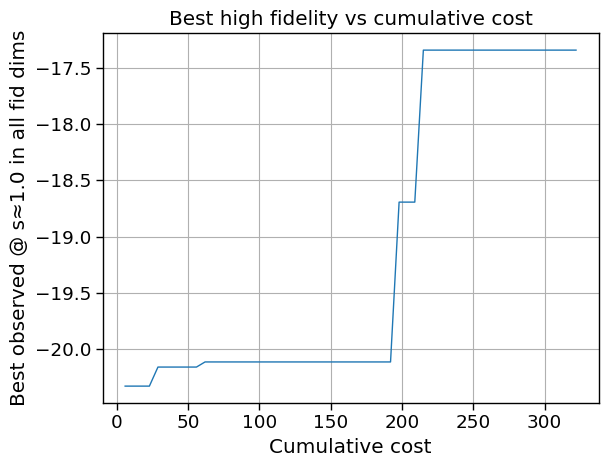

Iter 01 | s=[1.000] | y=-20.569 | cost=6.000 | cum_cost=6.000 | best_hf=-20.569
Iter 02 | s=[0.000] | y=-18.349 | cost=5.000 | cum_cost=11.000 | best_hf=-20.569
Iter 03 | s=[0.000] | y=-18.023 | cost=5.000 | cum_cost=16.000 | best_hf=-20.569
Iter 04 | s=[1.000] | y=-21.344 | cost=6.000 | cum_cost=22.000 | best_hf=-20.569
Iter 05 | s=[1.000] | y=-20.910 | cost=6.000 | cum_cost=28.000 | best_hf=-20.569
Iter 06 | s=[0.000] | y=-18.233 | cost=5.000 | cum_cost=33.000 | best_hf=-20.569
Iter 07 | s=[1.000] | y=-21.165 | cost=6.000 | cum_cost=39.000 | best_hf=-20.569
Iter 08 | s=[1.000] | y=-21.728 | cost=6.000 | cum_cost=45.000 | best_hf=-20.569
Iter 09 | s=[0.000] | y=-18.254 | cost=5.000 | cum_cost=50.000 | best_hf=-20.569
Iter 10 | s=[1.000] | y=-18.950 | cost=6.000 | cum_cost=56.000 | best_hf=-18.950
Iter 11 | s=[1.000] | y=-21.012 | cost=6.000 | cum_cost=62.000 | best_hf=-18.950
Iter 12 | s=[1.000] | y=-20.122 | cost=6.000 | cum_cost=68.000 | best_hf=-18.950
Iter 13 | s=[1.000] | y=-21.6

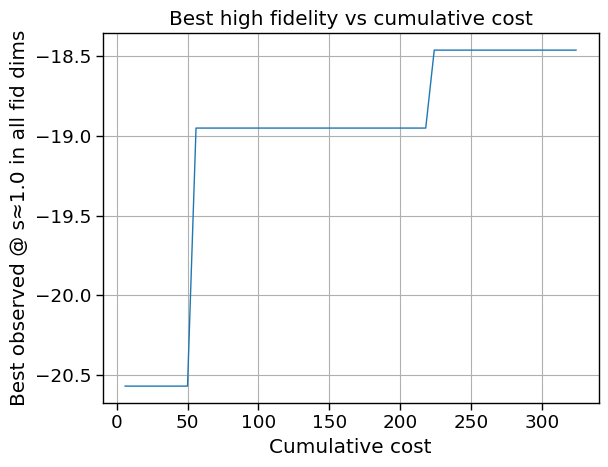

Saved aggregate stats → mf_kg_cont_runs_ackley_32.csv


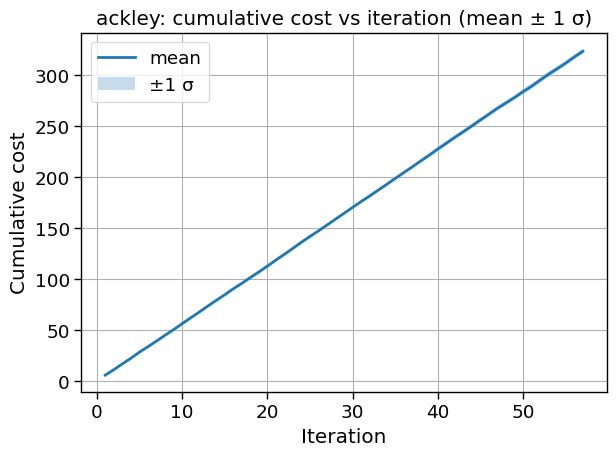

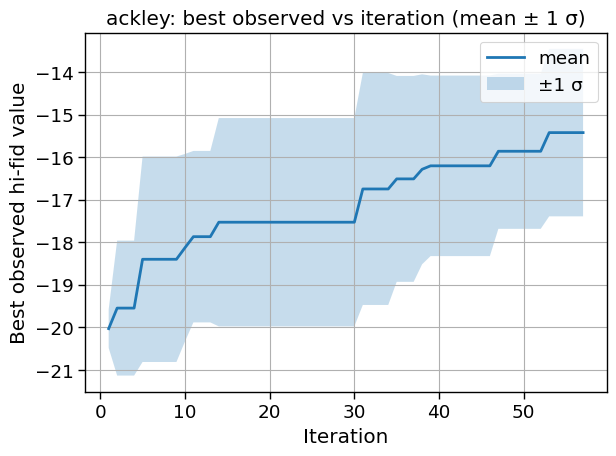

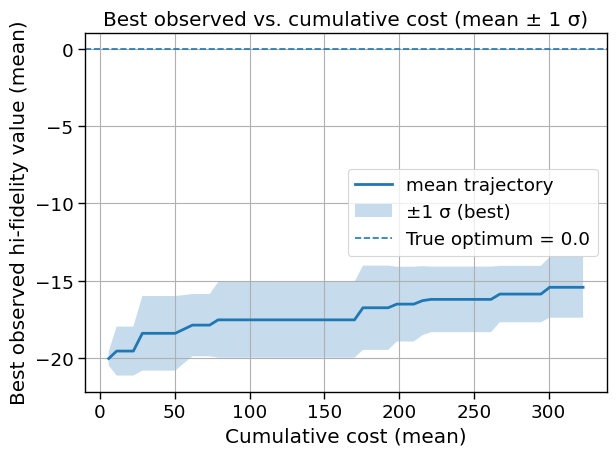


=== Running rastrigin (iters=50) ===
Iter 01 | s=[1.000] | y=-34.924 | cost=6.000 | cum_cost=6.000 | best_hf=-34.924
Iter 02 | s=[1.000] | y=-66.896 | cost=6.000 | cum_cost=12.000 | best_hf=-34.924
Iter 03 | s=[0.000] | y=-65.580 | cost=5.000 | cum_cost=17.000 | best_hf=-34.924
Iter 04 | s=[1.000] | y=-49.823 | cost=6.000 | cum_cost=23.000 | best_hf=-34.924
Iter 05 | s=[1.000] | y=-32.226 | cost=6.000 | cum_cost=29.000 | best_hf=-32.226
Iter 06 | s=[1.000] | y=-68.237 | cost=6.000 | cum_cost=35.000 | best_hf=-32.226
Iter 07 | s=[1.000] | y=-66.996 | cost=6.000 | cum_cost=41.000 | best_hf=-32.226
Iter 08 | s=[1.000] | y=-72.779 | cost=6.000 | cum_cost=47.000 | best_hf=-32.226
Iter 09 | s=[1.000] | y=-46.913 | cost=6.000 | cum_cost=53.000 | best_hf=-32.226
Iter 10 | s=[1.000] | y=-36.801 | cost=6.000 | cum_cost=59.000 | best_hf=-32.226
Iter 11 | s=[1.000] | y=-87.848 | cost=6.000 | cum_cost=65.000 | best_hf=-32.226
Iter 12 | s=[1.000] | y=-50.441 | cost=6.000 | cum_cost=71.000 | best_hf

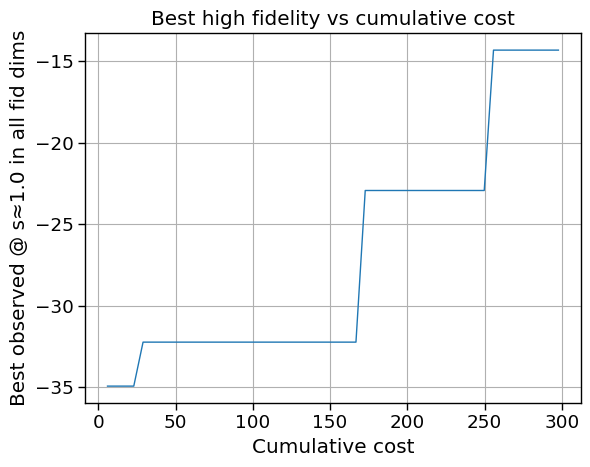

Iter 01 | s=[1.000] | y=-37.464 | cost=6.000 | cum_cost=6.000 | best_hf=-37.464
Iter 02 | s=[1.000] | y=-78.198 | cost=6.000 | cum_cost=12.000 | best_hf=-37.464
Iter 03 | s=[1.000] | y=-68.785 | cost=6.000 | cum_cost=18.000 | best_hf=-37.464
Iter 04 | s=[1.000] | y=-54.632 | cost=6.000 | cum_cost=24.000 | best_hf=-37.464
Iter 05 | s=[1.000] | y=-59.005 | cost=6.000 | cum_cost=30.000 | best_hf=-37.464
Iter 06 | s=[1.000] | y=-78.364 | cost=6.000 | cum_cost=36.000 | best_hf=-37.464
Iter 07 | s=[1.000] | y=-55.634 | cost=6.000 | cum_cost=42.000 | best_hf=-37.464
Iter 08 | s=[1.000] | y=-64.214 | cost=6.000 | cum_cost=48.000 | best_hf=-37.464
Iter 09 | s=[1.000] | y=-30.899 | cost=6.000 | cum_cost=54.000 | best_hf=-30.899
Iter 10 | s=[1.000] | y=-67.674 | cost=6.000 | cum_cost=60.000 | best_hf=-30.899
Iter 11 | s=[1.000] | y=-63.862 | cost=6.000 | cum_cost=66.000 | best_hf=-30.899
Iter 12 | s=[1.000] | y=-19.334 | cost=6.000 | cum_cost=72.000 | best_hf=-19.334
Iter 13 | s=[1.000] | y=-55.9

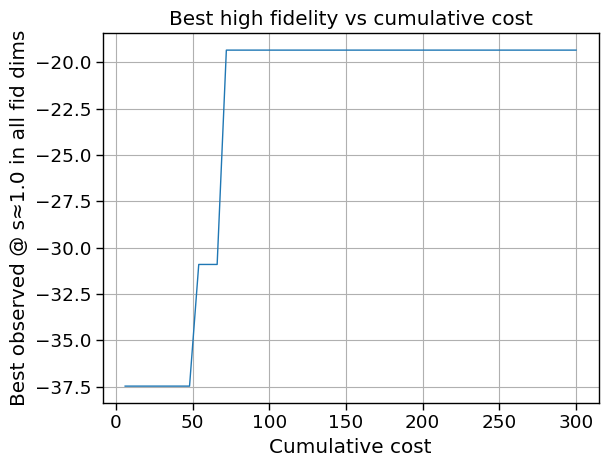

Iter 01 | s=[1.000] | y=-52.701 | cost=6.000 | cum_cost=6.000 | best_hf=-44.995
Iter 02 | s=[1.000] | y=-53.479 | cost=6.000 | cum_cost=12.000 | best_hf=-44.995
Iter 03 | s=[1.000] | y=-61.632 | cost=6.000 | cum_cost=18.000 | best_hf=-44.995
Iter 04 | s=[1.000] | y=-63.627 | cost=6.000 | cum_cost=24.000 | best_hf=-44.995
Iter 05 | s=[1.000] | y=-25.304 | cost=6.000 | cum_cost=30.000 | best_hf=-25.304
Iter 06 | s=[1.000] | y=-51.172 | cost=6.000 | cum_cost=36.000 | best_hf=-25.304
Iter 07 | s=[1.000] | y=-69.220 | cost=6.000 | cum_cost=42.000 | best_hf=-25.304
Iter 08 | s=[1.000] | y=-17.422 | cost=6.000 | cum_cost=48.000 | best_hf=-17.422
Iter 09 | s=[1.000] | y=-23.418 | cost=6.000 | cum_cost=54.000 | best_hf=-17.422
Iter 10 | s=[1.000] | y=-20.573 | cost=6.000 | cum_cost=60.000 | best_hf=-17.422
Iter 11 | s=[1.000] | y=-74.059 | cost=6.000 | cum_cost=66.000 | best_hf=-17.422
Iter 12 | s=[1.000] | y=-54.381 | cost=6.000 | cum_cost=72.000 | best_hf=-17.422
Iter 13 | s=[1.000] | y=-69.3

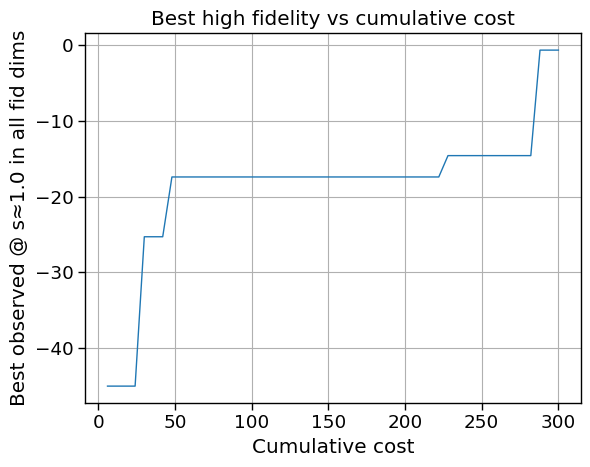

Iter 01 | s=[1.000] | y=-77.994 | cost=6.000 | cum_cost=6.000 | best_hf=-18.746
Iter 02 | s=[1.000] | y=-56.287 | cost=6.000 | cum_cost=12.000 | best_hf=-18.746
Iter 03 | s=[1.000] | y=-47.121 | cost=6.000 | cum_cost=18.000 | best_hf=-18.746
Iter 04 | s=[1.000] | y=-21.976 | cost=6.000 | cum_cost=24.000 | best_hf=-18.746
Iter 05 | s=[1.000] | y=-26.601 | cost=6.000 | cum_cost=30.000 | best_hf=-18.746
Iter 06 | s=[1.000] | y=-49.525 | cost=6.000 | cum_cost=36.000 | best_hf=-18.746
Iter 07 | s=[1.000] | y=-60.396 | cost=6.000 | cum_cost=42.000 | best_hf=-18.746
Iter 08 | s=[1.000] | y=-89.635 | cost=6.000 | cum_cost=48.000 | best_hf=-18.746
Iter 09 | s=[1.000] | y=-62.416 | cost=6.000 | cum_cost=54.000 | best_hf=-18.746
Iter 10 | s=[1.000] | y=-40.092 | cost=6.000 | cum_cost=60.000 | best_hf=-18.746
Iter 11 | s=[1.000] | y=-33.537 | cost=6.000 | cum_cost=66.000 | best_hf=-18.746
Iter 12 | s=[1.000] | y=-53.568 | cost=6.000 | cum_cost=72.000 | best_hf=-18.746
Iter 13 | s=[1.000] | y=-63.8

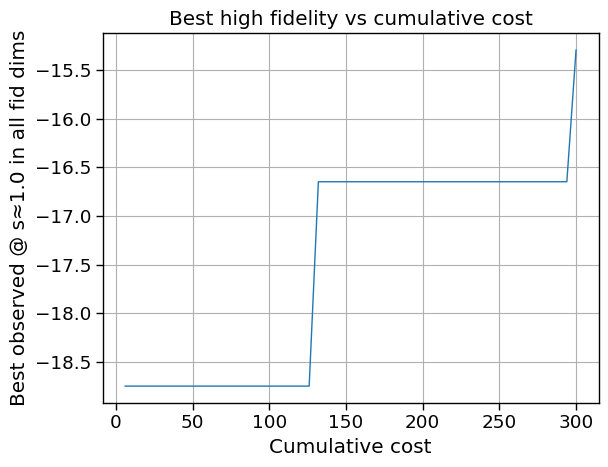

Iter 01 | s=[1.000] | y=-33.850 | cost=6.000 | cum_cost=6.000 | best_hf=-31.370
Iter 02 | s=[1.000] | y=-64.531 | cost=6.000 | cum_cost=12.000 | best_hf=-31.370
Iter 03 | s=[1.000] | y=-46.162 | cost=6.000 | cum_cost=18.000 | best_hf=-31.370
Iter 04 | s=[1.000] | y=-84.957 | cost=6.000 | cum_cost=24.000 | best_hf=-31.370
Iter 05 | s=[1.000] | y=-61.381 | cost=6.000 | cum_cost=30.000 | best_hf=-31.370
Iter 06 | s=[1.000] | y=-51.241 | cost=6.000 | cum_cost=36.000 | best_hf=-31.370
Iter 07 | s=[1.000] | y=-74.290 | cost=6.000 | cum_cost=42.000 | best_hf=-31.370
Iter 08 | s=[1.000] | y=-58.886 | cost=6.000 | cum_cost=48.000 | best_hf=-31.370
Iter 09 | s=[1.000] | y=-38.000 | cost=6.000 | cum_cost=54.000 | best_hf=-31.370
Iter 10 | s=[1.000] | y=-81.387 | cost=6.000 | cum_cost=60.000 | best_hf=-31.370
Iter 11 | s=[1.000] | y=-51.708 | cost=6.000 | cum_cost=66.000 | best_hf=-31.370
Iter 12 | s=[1.000] | y=-22.642 | cost=6.000 | cum_cost=72.000 | best_hf=-22.642
Iter 13 | s=[1.000] | y=-32.5

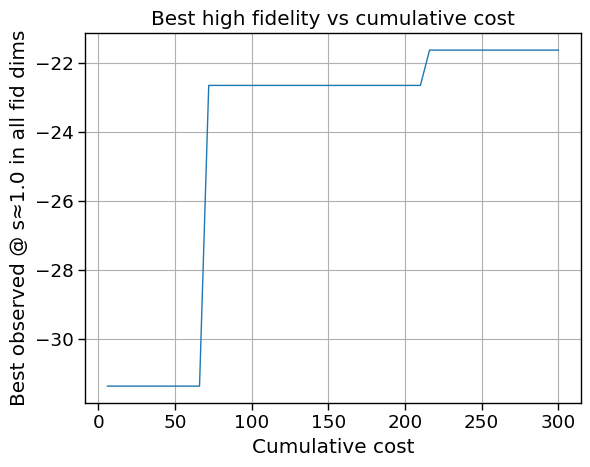

Iter 01 | s=[1.000] | y=-51.865 | cost=6.000 | cum_cost=6.000 | best_hf=-34.842
Iter 02 | s=[1.000] | y=-79.790 | cost=6.000 | cum_cost=12.000 | best_hf=-34.842
Iter 03 | s=[1.000] | y=-53.638 | cost=6.000 | cum_cost=18.000 | best_hf=-34.842
Iter 04 | s=[1.000] | y=-45.066 | cost=6.000 | cum_cost=24.000 | best_hf=-34.842
Iter 05 | s=[1.000] | y=-54.123 | cost=6.000 | cum_cost=30.000 | best_hf=-34.842
Iter 06 | s=[1.000] | y=-38.225 | cost=6.000 | cum_cost=36.000 | best_hf=-34.842
Iter 07 | s=[1.000] | y=-75.658 | cost=6.000 | cum_cost=42.000 | best_hf=-34.842
Iter 08 | s=[1.000] | y=-61.814 | cost=6.000 | cum_cost=48.000 | best_hf=-34.842
Iter 09 | s=[1.000] | y=-33.878 | cost=6.000 | cum_cost=54.000 | best_hf=-33.878
Iter 10 | s=[1.000] | y=-44.610 | cost=6.000 | cum_cost=60.000 | best_hf=-33.878
Iter 11 | s=[1.000] | y=-58.929 | cost=6.000 | cum_cost=66.000 | best_hf=-33.878
Iter 12 | s=[1.000] | y=-39.130 | cost=6.000 | cum_cost=72.000 | best_hf=-33.878
Iter 13 | s=[1.000] | y=-37.5

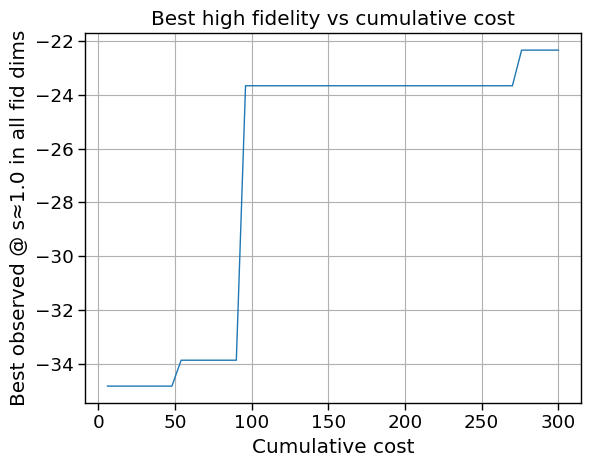

Saved aggregate stats → mf_kg_cont_runs_rastrigin_32.csv


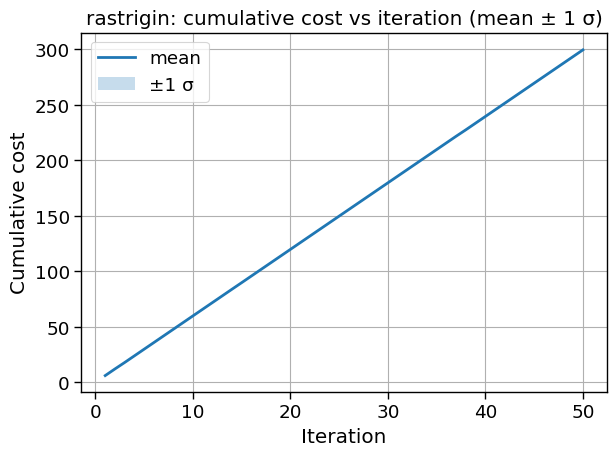

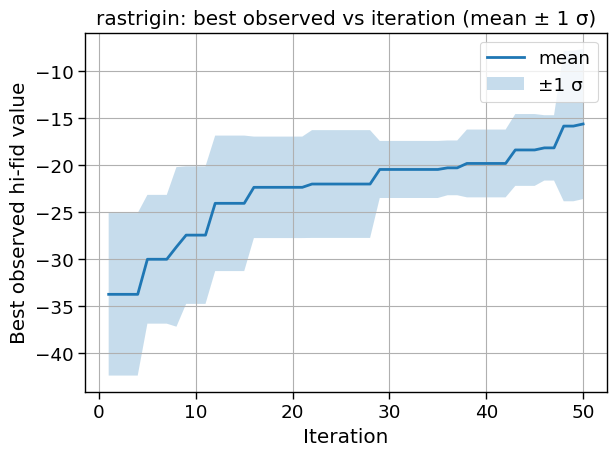

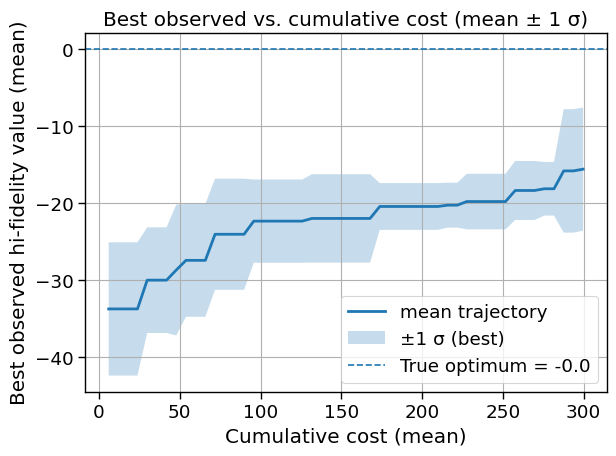


=== Running suzuki_mf (iters=60) ===
Iter 01 | s=[1.000] | y=66.098 | cost=6.000 | cum_cost=6.000 | best_hf=66.098
Iter 02 | s=[1.000] | y=68.328 | cost=6.000 | cum_cost=12.000 | best_hf=68.328
Iter 03 | s=[1.000] | y=70.796 | cost=6.000 | cum_cost=18.000 | best_hf=70.796
Iter 04 | s=[1.000] | y=70.381 | cost=6.000 | cum_cost=24.000 | best_hf=70.796
Iter 05 | s=[1.000] | y=67.436 | cost=6.000 | cum_cost=30.000 | best_hf=70.796
Iter 06 | s=[1.000] | y=69.299 | cost=6.000 | cum_cost=36.000 | best_hf=70.796
Iter 07 | s=[1.000] | y=74.506 | cost=6.000 | cum_cost=42.000 | best_hf=74.506
Iter 08 | s=[1.000] | y=75.896 | cost=6.000 | cum_cost=48.000 | best_hf=75.896
Iter 09 | s=[1.000] | y=76.893 | cost=6.000 | cum_cost=54.000 | best_hf=76.893
Iter 10 | s=[1.000] | y=78.818 | cost=6.000 | cum_cost=60.000 | best_hf=78.818
Iter 11 | s=[1.000] | y=75.344 | cost=6.000 | cum_cost=66.000 | best_hf=78.818
Iter 12 | s=[1.000] | y=79.677 | cost=6.000 | cum_cost=72.000 | best_hf=79.677
Iter 13 | s=[1.

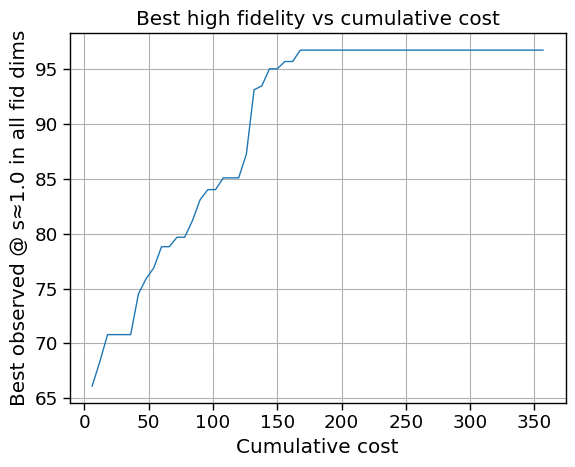

Iter 01 | s=[1.000] | y=70.128 | cost=6.000 | cum_cost=6.000 | best_hf=70.128
Iter 02 | s=[1.000] | y=70.921 | cost=6.000 | cum_cost=12.000 | best_hf=70.921
Iter 03 | s=[1.000] | y=50.820 | cost=6.000 | cum_cost=18.000 | best_hf=70.921
Iter 04 | s=[1.000] | y=57.834 | cost=6.000 | cum_cost=24.000 | best_hf=70.921
Iter 05 | s=[1.000] | y=69.778 | cost=6.000 | cum_cost=30.000 | best_hf=70.921
Iter 06 | s=[1.000] | y=77.126 | cost=6.000 | cum_cost=36.000 | best_hf=77.126
Iter 07 | s=[1.000] | y=84.472 | cost=6.000 | cum_cost=42.000 | best_hf=84.472
Iter 08 | s=[1.000] | y=86.025 | cost=6.000 | cum_cost=48.000 | best_hf=86.025
Iter 09 | s=[1.000] | y=63.578 | cost=6.000 | cum_cost=54.000 | best_hf=86.025
Iter 10 | s=[1.000] | y=65.018 | cost=6.000 | cum_cost=60.000 | best_hf=86.025
Iter 11 | s=[1.000] | y=69.440 | cost=6.000 | cum_cost=66.000 | best_hf=86.025
Iter 12 | s=[1.000] | y=89.065 | cost=6.000 | cum_cost=72.000 | best_hf=89.065
Iter 13 | s=[1.000] | y=71.230 | cost=6.000 | cum_cos

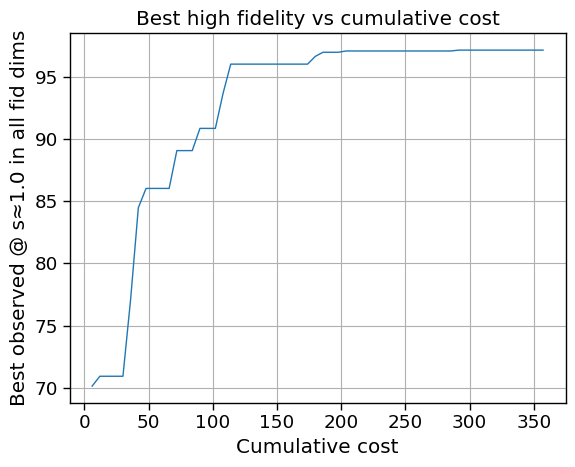

Iter 01 | s=[1.000] | y=55.659 | cost=6.000 | cum_cost=6.000 | best_hf=75.097
Iter 02 | s=[1.000] | y=21.859 | cost=6.000 | cum_cost=12.000 | best_hf=75.097
Iter 03 | s=[1.000] | y=15.045 | cost=6.000 | cum_cost=18.000 | best_hf=75.097
Iter 04 | s=[1.000] | y=77.619 | cost=6.000 | cum_cost=24.000 | best_hf=77.619
Iter 05 | s=[1.000] | y=72.706 | cost=6.000 | cum_cost=30.000 | best_hf=77.619
Iter 06 | s=[1.000] | y=79.910 | cost=6.000 | cum_cost=36.000 | best_hf=79.910
Iter 07 | s=[1.000] | y=86.437 | cost=6.000 | cum_cost=42.000 | best_hf=86.437
Iter 08 | s=[1.000] | y=88.947 | cost=6.000 | cum_cost=48.000 | best_hf=88.947
Iter 09 | s=[1.000] | y=30.200 | cost=6.000 | cum_cost=54.000 | best_hf=88.947
Iter 10 | s=[1.000] | y=12.448 | cost=6.000 | cum_cost=60.000 | best_hf=88.947
Iter 11 | s=[1.000] | y=49.667 | cost=6.000 | cum_cost=66.000 | best_hf=88.947
Iter 12 | s=[1.000] | y=90.698 | cost=6.000 | cum_cost=72.000 | best_hf=90.698
Iter 13 | s=[1.000] | y=63.846 | cost=6.000 | cum_cos

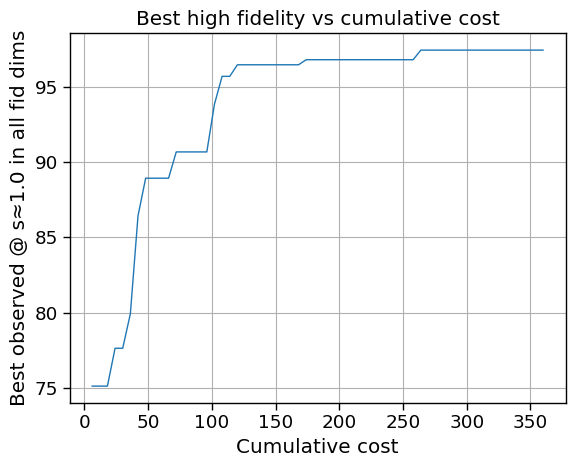

Iter 01 | s=[1.000] | y=27.589 | cost=6.000 | cum_cost=6.000 | best_hf=55.848
Iter 02 | s=[1.000] | y=72.077 | cost=6.000 | cum_cost=12.000 | best_hf=72.077
Iter 03 | s=[1.000] | y=71.454 | cost=6.000 | cum_cost=18.000 | best_hf=72.077
Iter 04 | s=[1.000] | y=59.267 | cost=6.000 | cum_cost=24.000 | best_hf=72.077
Iter 05 | s=[1.000] | y=70.111 | cost=6.000 | cum_cost=30.000 | best_hf=72.077
Iter 06 | s=[1.000] | y=71.964 | cost=6.000 | cum_cost=36.000 | best_hf=72.077
Iter 07 | s=[1.000] | y=72.024 | cost=6.000 | cum_cost=42.000 | best_hf=72.077
Iter 08 | s=[1.000] | y=77.500 | cost=6.000 | cum_cost=48.000 | best_hf=77.500
Iter 09 | s=[1.000] | y=82.581 | cost=6.000 | cum_cost=54.000 | best_hf=82.581
Iter 10 | s=[1.000] | y=85.877 | cost=6.000 | cum_cost=60.000 | best_hf=85.877
Iter 11 | s=[1.000] | y=68.564 | cost=6.000 | cum_cost=66.000 | best_hf=85.877
Iter 12 | s=[1.000] | y=69.600 | cost=6.000 | cum_cost=72.000 | best_hf=85.877
Iter 13 | s=[1.000] | y=88.061 | cost=6.000 | cum_cos

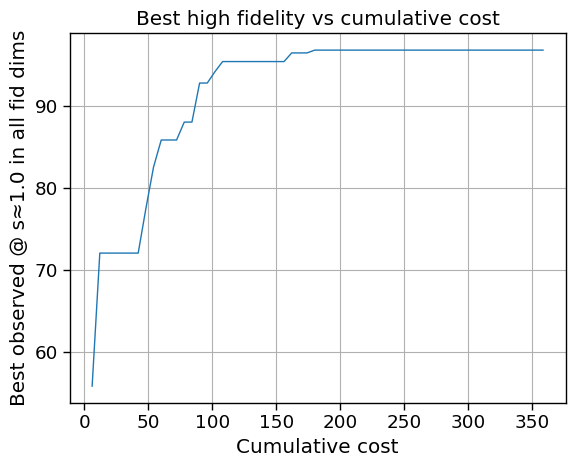

Iter 01 | s=[1.000] | y=45.830 | cost=6.000 | cum_cost=6.000 | best_hf=75.926
Iter 02 | s=[1.000] | y=71.547 | cost=6.000 | cum_cost=12.000 | best_hf=75.926
Iter 03 | s=[1.000] | y=79.286 | cost=6.000 | cum_cost=18.000 | best_hf=79.286
Iter 04 | s=[1.000] | y=68.138 | cost=6.000 | cum_cost=24.000 | best_hf=79.286
Iter 05 | s=[1.000] | y=80.991 | cost=6.000 | cum_cost=30.000 | best_hf=80.991
Iter 06 | s=[1.000] | y=80.676 | cost=6.000 | cum_cost=36.000 | best_hf=80.991
Iter 07 | s=[1.000] | y=80.329 | cost=6.000 | cum_cost=42.000 | best_hf=80.991
Iter 08 | s=[1.000] | y=86.993 | cost=6.000 | cum_cost=48.000 | best_hf=86.993
Iter 09 | s=[1.000] | y=88.785 | cost=6.000 | cum_cost=54.000 | best_hf=88.785
Iter 10 | s=[1.000] | y=87.283 | cost=6.000 | cum_cost=60.000 | best_hf=88.785
Iter 11 | s=[1.000] | y=91.353 | cost=6.000 | cum_cost=66.000 | best_hf=91.353
Iter 12 | s=[1.000] | y=46.203 | cost=6.000 | cum_cost=72.000 | best_hf=91.353
Iter 13 | s=[1.000] | y=91.924 | cost=6.000 | cum_cos

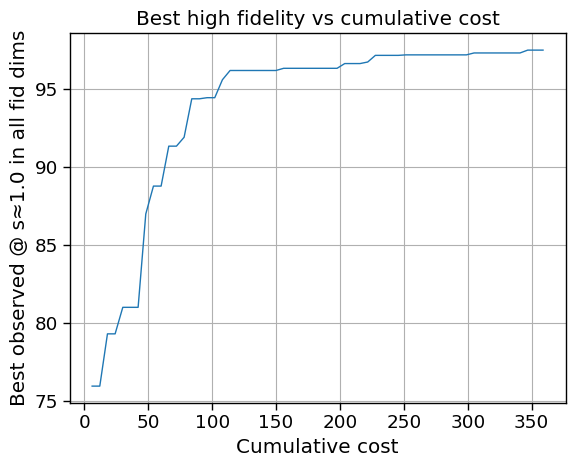

Iter 01 | s=[1.000] | y=57.563 | cost=6.000 | cum_cost=6.000 | best_hf=57.563
Iter 02 | s=[0.952] | y=59.976 | cost=5.952 | cum_cost=11.952 | best_hf=57.563
Iter 03 | s=[0.478] | y=57.010 | cost=5.478 | cum_cost=17.430 | best_hf=57.563
Iter 04 | s=[0.581] | y=65.695 | cost=5.581 | cum_cost=23.011 | best_hf=57.563
Iter 05 | s=[0.713] | y=62.798 | cost=5.713 | cum_cost=28.724 | best_hf=57.563
Iter 06 | s=[0.774] | y=64.212 | cost=5.774 | cum_cost=34.499 | best_hf=57.563
Iter 07 | s=[1.000] | y=51.274 | cost=6.000 | cum_cost=40.499 | best_hf=57.563
Iter 08 | s=[0.979] | y=65.318 | cost=5.979 | cum_cost=46.478 | best_hf=57.563
Iter 09 | s=[0.991] | y=68.095 | cost=5.991 | cum_cost=52.468 | best_hf=68.095
Iter 10 | s=[1.000] | y=69.961 | cost=6.000 | cum_cost=58.468 | best_hf=69.961
Iter 11 | s=[1.000] | y=71.421 | cost=6.000 | cum_cost=64.468 | best_hf=71.421
Iter 12 | s=[1.000] | y=74.246 | cost=6.000 | cum_cost=70.468 | best_hf=74.246
Iter 13 | s=[1.000] | y=76.095 | cost=6.000 | cum_cos

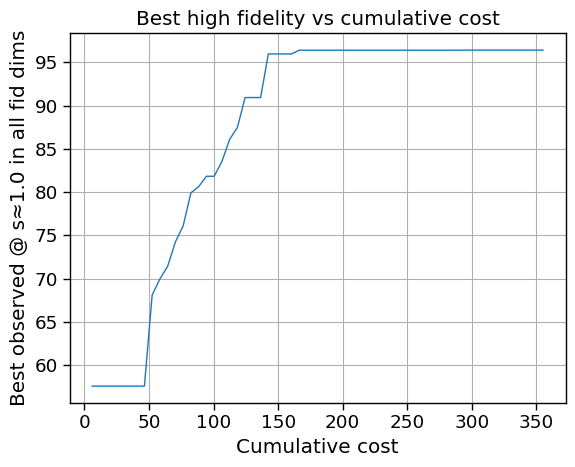

Saved aggregate stats → mf_kg_cont_runs_suzuki_mf_32.csv


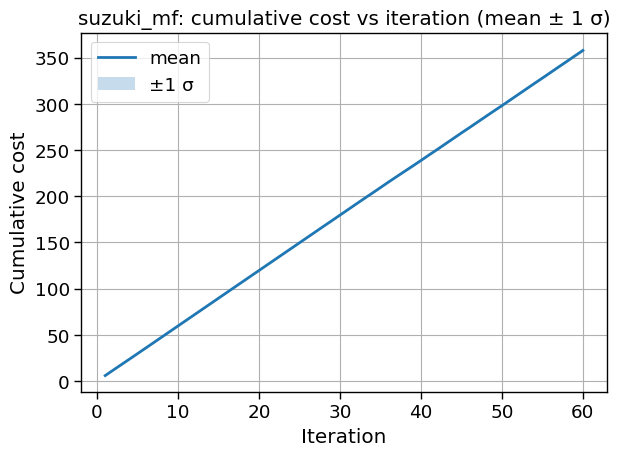

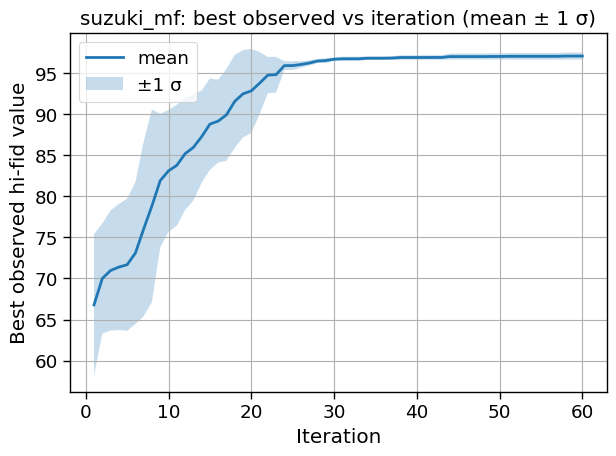

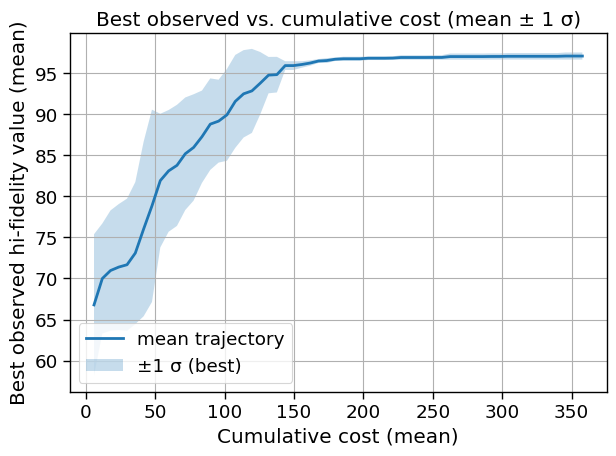

In [ ]:
import matplotlib.pyplot as plt
from collections import OrderedDict

# ------------------------------------------------------------------
# 0)  Benchmarks and their custom settings
# ------------------------------------------------------------------
benchmarks = OrderedDict([
    ("hartmann",   (AugmentedHartmann(negate=True), 60,  3.32237)),
    ("branin",     (AugmentedBranin(negate=True), 50, -0.3978)),
    ("bukin",      (AugmentedBukin(negate=True), 50, -0.0)),
    ("ackley",  (AugmentedAckley(dim=3, negate=True), 57,  0.0)),
    ("rastrigin",  (AugmentedRastrigin(dim=3, negate=True), 50, -0.0)),
    ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True),60, None)),
])

SEEDS = [ 33, 42, 88, 105, 67, 151,]  # 5 runs each 

# ------------------------------------------------------------------
# 1)  Loop over benchmarks
# ------------------------------------------------------------------
for tag, (f, total_iters, opt_val) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    # 1a) independent runs
    run_dfs = [run_single(f=f, seed=s, total_iters=total_iters) for s in SEEDS]

    # # 1b) aggregate & save
    stats_df = aggregate_runs(run_dfs)
    out_csv  = f"mf_kg_cont_runs_{tag}.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats → {out_csv}")

    # 1c) plots
    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        optimum_val=opt_val,          # show dashed line only if not None
    )
    plt.show()
# ------------------------------------------------------------------

